In [165]:
# %% Imports and config
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import math
from torch.utils.data import Dataset
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import torch
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import copy
import re
from sklearn.metrics import mean_absolute_error, mean_squared_error


# --- CONFIG ---
BATCH_SIZE = 512
EPOCHS = 15
LEARNING_RATE = 1e-5
KFOLDS = 5
TEST_SPLIT = 0.2
SEED = 2222

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [166]:
class TimeSeriesDataset(Dataset):
    def __init__(self, csv_files, step=1, input_range=(-1, 1), target_range=(-1, 1), value_clip=1e5):
        self.data = []
        self.target = []

        print(f"📂 Processing {len(csv_files)} files")
        if not csv_files:
            raise ValueError("❌ No CSV files provided.")

        for file in csv_files:
            try:
                df = pd.read_csv(file)
                '''if df.shape[1] < 6:
                    print(f"⚠️ Skipping {file}: too few columns")
                    continue'''

                # Pretpostavka: kolone su [time, value, next_time, next_value]
                df = df.iloc[::step, :]
                df.columns = ['time', 'value', "top", "bot", 'time_step', "L_value", "next_value"]

                time = df['time'].values
                time_step = df['time_step'].values
                value = df['value'].values
                next_value = df['next_value'].values
                top = df['top'].values
                bot = df['bot'].values
                L_val = df['L_value'].values

                # === Binarizuj sw_state ulaze ==
                top = (top > 0.5).astype(float)
                bot = (bot > 0.5).astype(float)
                
                # Detekcija tranzicija (promena stanja)
                top_change = np.abs(np.diff(top, prepend=top[0]))
                bot_change = np.abs(np.diff(bot, prepend=bot[0]))

                # Čišćenje
                valid_mask = (
                    np.isfinite(time) &
                    np.isfinite(time_step) &
                    np.isfinite(top) &
                    np.isfinite(bot) &
                    np.isfinite(value) &
                    np.isfinite(next_value) &
                    (np.abs(value) < value_clip) &
                    (np.abs(next_value) < value_clip) &
                    (np.abs(L_val) < value_clip)
                )



                if not np.any(valid_mask):
                    print(f"⚠️ Skipping {file}: no valid rows after filtering")
                    continue

                time       = time       [valid_mask]
                value      = value      [valid_mask]
                next_value = next_value [valid_mask]
                L_val      = L_val      [valid_mask]

                # Novi ulazni format: [time, next_time, value]
                inputs = np.stack([value, top, bot, time_step, L_val], axis=1)
                self.data.append(inputs)
                self.target.append(next_value)

            except Exception as e:
                print(f"❌ Failed to process {file}: {e}")
                continue

        # ✅ Finalna obrada
        self.data = np.concatenate(self.data, axis=0)
        self.target = np.concatenate(self.target, axis=0)

        # Normalizacija
        self.scaler_X = MinMaxScaler(feature_range=input_range)
        self.scaler_y = MinMaxScaler(feature_range=target_range)

        self.data = self.scaler_X.fit_transform(self.data)
        self.target = self.scaler_y.fit_transform(self.target.reshape(-1, 1)).flatten()

        print(f"✅ Loaded {len(self.data)} samples from {len(csv_files)} files.")
        print(f"📊 Input shape: {self.data.shape}, Target shape: {self.target.shape}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.data[idx], dtype=torch.float32),
            torch.tensor(self.target[idx], dtype=torch.float32)
        )

    def get_scalers(self):
        return self.scaler_X, self.scaler_y


In [167]:
class SinCosActivation(nn.Module):
    def __init__(self, alpha=1.0, beta = 1.0, gamma = 1.0, delta = 1.0, epsilon = 0):
        super().__init__()
        self.alpha   = nn.Parameter(torch.tensor(alpha, dtype=torch.float32))
        self.beta    = nn.Parameter(torch.tensor(beta, dtype=torch.float32))
        self.gamma   = nn.Parameter(torch.tensor(gamma, dtype=torch.float32))
        self.delta   = nn.Parameter(torch.tensor(delta, dtype=torch.float32))
        self.epsilon = nn.Parameter(torch.tensor(epsilon, dtype=torch.float32))
    def forward(self, x):
        return ((self.delta * (torch.sin(self.alpha)) + (torch.cos(self.beta)) * self.gamma)  + self.epsilon)*x


In [168]:
class FeedforwardNet(nn.Module):
    def __init__(self, input_size=5, hidden_layers=6, neurons_per_layer=256, output_size=1):
        super().__init__()

        layers = []
        prev_size = input_size

        for _ in range(hidden_layers):
            layers.append(nn.Linear(prev_size, neurons_per_layer))
            layers.append(SinCosActivation())  # Trenabilna aktivacija
            prev_size = neurons_per_layer

        layers.append(nn.Linear(prev_size, output_size))
        self.model = nn.Sequential(*layers)
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.model(x)

In [169]:
def physics_loss(pred, inputs, Vout_pu=0.2):
    # inputs: [value, top, bot, time_step, L_value]
    value = inputs[:, 0]
    top   = inputs[:, 1]
    bot   = inputs[:, 2]
    dt    = inputs[:, 3]
    L     = inputs[:, 4]

    V_DC = 10 * Vout_pu  

    V_L_target = V_DC * (top - bot)
    dI_dt = 150 * torch.tanh((pred.squeeze() - value) / dt / 150)


    V_L_pred = L * dI_dt

    return torch.mean((V_L_pred - V_L_target)**2)


In [170]:
import torch, torch.nn.functional as F
from torch.nn.utils import clip_grad_norm_
from collections import defaultdict
from tqdm.auto import tqdm


# ───────────────────────────────────────────────────
def _compute_components(pred, target, inputs, λ_phys):
    mse = F.mse_loss(pred.squeeze(), target)

    peak   = torch.clamp((pred.max() - target.max()), -1., 1.) ** 2
    trough = torch.clamp((pred.min() - target.min()), -1., 1.) ** 2
    shape  = 0.20 * (peak + trough)

    phys   = λ_phys * physics_loss(pred, inputs) if λ_phys else torch.tensor(0., device=pred.device)
    total  = mse + shape + phys
    return total, mse, shape, phys
# ───────────────────────────────────────────────────

def make_log_schedule(lam_start, lam_end, n_epochs, delay_epochs=0):
    log_part = np.logspace(np.log10(lam_start), np.log10(lam_end), num=n_epochs - delay_epochs)
    return np.concatenate([np.full(delay_epochs, lam_start), log_part])



def train_fold(
    model,
    train_loader,
    val_loader,
    *,
    n_epochs: int   = 50,
    lr: float       = 3e-4,
    weight_decay: float = 1e-4,
    clip_grad: float = 1.0,
    patience: int   = 5,
    device: torch.device = None,
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    initial_lr = 1e-4
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)


    best_val, best_sd, stall = float("inf"), None, 0
    history = defaultdict(list)          # ⬅️  metrics container

    λ_sched = make_log_schedule(1e-4, 1.0, n_epochs, 10)

    for epoch in range(1, n_epochs + 1):
        # ――― TRAIN ―――
        model.train()
        sums = defaultdict(float)        # accumulate weighted sums
        for X, y in tqdm(train_loader, desc=f"Epoch {epoch:02d}", leave=False):
            X, y = X.to(device), y.to(device)
            opt.zero_grad()
            λ_now = float(λ_sched[epoch - 1]) 
            y_hat = model(X)
            total, mse, shape, phys = _compute_components(y_hat, y, X, λ_now)
            total.backward()

            grad_norm = clip_grad_norm_(model.parameters(), clip_grad).item()
            opt.step()

            bsz = X.size(0)
            sums["total"] += total.item() * bsz
            sums["mse"]   += mse.item()   * bsz
            sums["shape"] += shape.item() * bsz
            sums["phys"]  += phys.item()  * bsz
            sums["grad"]  += grad_norm    * bsz   # average later

        n_train = len(train_loader.dataset)
        history["train_total"].append(sums["total"] / n_train)
        history["train_mse"  ].append(sums["mse"]   / n_train)
        history["train_shape"].append(sums["shape"] / n_train)
        history["train_phys" ].append(sums["phys"]  / n_train)
        history["grad_norm"  ].append(sums["grad"]  / n_train)   # mean grad-norm
        history["lr"].append(opt.param_groups[0]["lr"])

        # ――― VALIDATE ―――
        model.eval()
        with torch.no_grad():
            sums = defaultdict(float)
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                λ_now = float(λ_sched[epoch - 1])
                total, mse, shape, phys = _compute_components(y_hat, y, X, λ_now) 
                bsz = X.size(0)
                sums["total"] += total.item() * bsz
                sums["mse"]   += mse.item()   * bsz
                sums["shape"] += shape.item() * bsz

        n_val = len(val_loader.dataset)
        history["val_total" ].append(sums["total"] / n_val)
        history["val_mse"   ].append(sums["mse"]   / n_val)
        history["val_shape" ].append(sums["shape"] / n_val)
        history["val_phys"  ].append(0.0)                    # always 0 on val

        # ――― scheduler / early-stop ―――
        val_metric = history["val_total"][-1]
        scheduler.step()

        if val_metric < best_val - 1e-4:
            best_val, best_sd, stall = val_metric, model.state_dict(), 0
        else:
            stall += 1
            if stall >= patience:
                print(f"⚠️  Early stop ({patience} epochs w/o improvement)")
                break

        print(f"Epoch {epoch:02d} | "
              f"T {history['train_total'][-1]:.6f} | "
              f"V {val_metric:.6f} | "
              f"LR {history['lr'][-1]:.2e} | "
              f"‖∇‖ {history['grad_norm'][-1]:.3f}")

    return best_sd, best_val, history, model


In [171]:
def cross_validate(
        dataset,
        hidden_layers: int      = 6,
        neurons_per_layer: int  = 256,
        input_size: int         = 5,
        *,
        n_epochs: int           = EPOCHS,
        lr: float               = 3e-4,
        λ_phys: float           = 1.0,
        weight_decay: float     = 1e-4,
        clip_grad: float        = 1.0,
):
    """
    K-fold CV wrapper oko nove train_fold().
    Vraća:
        best_state_dict         – parametri modela sa najmanjim val-loss-om
        test_set                – desetak % podataka za finalno testiranje
        all_histories           – lista dict-ova (po jedan po fold-u) sa
                                  kolonama train_total, val_total, lr, grad_norm …
        best_model              – instanca FeedforwardNet sa best_state_dict
    """
    # ――― Split na test + train/val ―――
    indices   = np.arange(len(dataset))
    np.random.shuffle(indices)
    test_size = int(TEST_SPLIT * len(indices))
    test_set  = Subset(dataset, indices[:test_size])
    train_val = Subset(dataset, indices[test_size:])

    kfold  = KFold(n_splits=KFOLDS, shuffle=True, random_state=SEED)

    all_histories      = []
    best_state_dict    = None
    best_model         = None
    best_val_overall   = float("inf")

    for fold, (tr_idx, va_idx) in enumerate(kfold.split(range(len(train_val)))):
        print(f"\n――― Fold {fold+1} / {KFOLDS} ―――")

        tr_loader = DataLoader(
            Subset(train_val, tr_idx), batch_size=BATCH_SIZE, shuffle=True
        )
        va_loader = DataLoader(
            Subset(train_val, va_idx), batch_size=BATCH_SIZE
        )

        model = FeedforwardNet(
            input_size=input_size,
            hidden_layers=hidden_layers,
            neurons_per_layer=neurons_per_layer
        ).to(device)

        best_sd_fold, best_val_fold, hist_fold, _ = train_fold(
            model, tr_loader, va_loader,
            n_epochs=n_epochs, lr=lr,
            weight_decay=weight_decay, clip_grad=clip_grad,
            device=device,
        )

        all_histories.append(hist_fold)

        # zadržavamo globalno najbolji model
        if best_val_fold < best_val_overall:
            best_val_overall = best_val_fold
            best_state_dict  = best_sd_fold
            best_model       = model
            best_model.load_state_dict(best_state_dict)   # sinhronizuj

        print(f"▶︎  Fold-{fold+1} best val = {best_val_fold:.6f}")

    return best_state_dict, test_set, all_histories, best_model, model


In [172]:
def plot_avg_loss_curves(train_losses, val_losses):
    max_len = max(len(t) for t in train_losses)

    def pad_with_nan(lst, target_len):
        return lst + [np.nan] * (target_len - len(lst))

    padded_train = np.array([pad_with_nan(t, max_len) for t in train_losses])
    padded_val = np.array([pad_with_nan(v, max_len) for v in val_losses])

    avg_train = np.nanmean(padded_train, axis=0)
    avg_val = np.nanmean(padded_val, axis=0)

    plt.figure(figsize=(10, 5))
    plt.plot(avg_train, label="Avg Train Loss")
    plt.plot(avg_val, label="Avg Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("Cross-Validation Loss Curves")
    plt.legend()
    plt.grid(True)
    plt.show()



In [173]:
if __name__ == "__main__":
    # Try different file name patterns - adjust this based on your actual file names
    patterns = ["half*""*"]
    
    for pattern in patterns:
        base = pattern.split("*")[0]
        csv_files = [f for f in os.listdir() if f.endswith("") and f.startswith("new")]
        if csv_files:
            print(f"Found {len(csv_files)} files with pattern '{pattern}'")
            break
    
    if not csv_files:
        print("No CSV files found. Please check your directory.")
        # List all files in directory for debugging
        print("Files in directory:", os.listdir())
        exit(1)
    
    csv_files = [
    "new_igbt_leg_L=1e-6_time_step_1e-6.csv",
    "new_igbt_leg_L=2e-6_time_step_2e-6.csv",    # nije postojao → uzimam 2e-6 sa manjim step
    "new_igbt_leg_L=5e-6_time_step_1e-6.csv",
    "new_igbt_leg_L=8e-6_time_step_1e-6.csv",
    "new_igbt_leg_L=1e-5_time_step_1e-6.csv",
    "new_igbt_leg_L=5e-5_time_step_1e-6.csv",
    "new_igbt_leg_L=1e-4_time_step_1e-6.csv",
    "new_igbt_leg_L=5e-4_time_step_1e-6.csv",
    "new_igbt_leg_L=1e-3_time_step_1e-6.csv",
    "new_igbt_leg_L=2e-3_time_step_2e-6.csv",    # fallback na 2e-3_time_step_2e-6
    "new_igbt_leg_L=5e-3_time_step_1e-6.csv",
    "new_igbt_leg_L=6e-3_time_step_1e-6.csv",
    "new_igbt_leg_L=7e-3_time_step_2e-6.csv",    # fallback na 2e-6 jer 1e-6 ne postoji
    "new_igbt_leg_L=1e-2_time_step_1e-6.csv",
    "new_igbt_leg_L=2e-2_time_step_2e-6.csv",    # fallback na 2e-6
    "new_igbt_leg_L=5e-2_time_step_2e-6.csv",    # fallback na 2e-6
    "new_igbt_leg_L=6e-2_time_step_2e-6.csv",    # fallback na 2e-6
    "new_igbt_leg_L=7e-2_time_step_2e-6.csv",    # fallback na 2e-6
    "new_igbt_leg_L=9e-2_time_step_1e-6.csv"
]


    # Ekstrakcija L i dt vrednosti
    '''records = []
    for file in csv_files:
        match = re.search(r"L=([\deE\-\+\.]+)_time_step_([\deE\-\+\.]+)", file)
        if match:
            L = float(match.group(1))
            dt = float(match.group(2))
            records.append((L, dt))

    # Kreiranje DataFrame-a
    df = pd.DataFrame(records, columns=["L", "dt"])

    # Plot
    plt.figure(figsize=(10, 6))
    plt.scatter(df["L"], df["dt"], s=100, c="royalblue", edgecolors='black')
    plt.xlabel("Inductance L (H)", fontsize=13)
    plt.ylabel("Time Step Δt (s)", fontsize=13)
    plt.title("Training Coverage: L vs Δt", fontsize=15)
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()'''
    # Create dataset
    dataset = TimeSeriesDataset(csv_files)

    print(csv_files)
    file_names = csv_files
    # After cross-validation
    input_size, hidden_layers, neurons_per_layer, output_size = 5, 7, 64, 1
    print("input_size:", input_size)
    print("hidden_layers:", hidden_layers)
    print("neurons_per_layer:", neurons_per_layer)
    print("output_size:", output_size)
    plt.style.use("default")
    #best_model_state_dict, test_set, train_losses, val_losses, model = cross_validate(dataset, input_size= input_size, hidden_layers=hidden_layers, neurons_per_layer=neurons_per_layer)


<>:44: SyntaxWarning: invalid escape sequence '\d'
<>:44: SyntaxWarning: invalid escape sequence '\d'
C:\Users\OgnjenPeric\AppData\Local\Temp\ipykernel_5596\3402278024.py:44: SyntaxWarning: invalid escape sequence '\d'
  match = re.search(r"L=([\deE\-\+\.]+)_time_step_([\deE\-\+\.]+)", file)


Found 65 files with pattern 'half**'
📂 Processing 19 files
✅ Loaded 2067168 samples from 19 files.
📊 Input shape: (2067168, 5), Target shape: (2067168,)
['new_igbt_leg_L=1e-6_time_step_1e-6.csv', 'new_igbt_leg_L=2e-6_time_step_2e-6.csv', 'new_igbt_leg_L=5e-6_time_step_1e-6.csv', 'new_igbt_leg_L=8e-6_time_step_1e-6.csv', 'new_igbt_leg_L=1e-5_time_step_1e-6.csv', 'new_igbt_leg_L=5e-5_time_step_1e-6.csv', 'new_igbt_leg_L=1e-4_time_step_1e-6.csv', 'new_igbt_leg_L=5e-4_time_step_1e-6.csv', 'new_igbt_leg_L=1e-3_time_step_1e-6.csv', 'new_igbt_leg_L=2e-3_time_step_2e-6.csv', 'new_igbt_leg_L=5e-3_time_step_1e-6.csv', 'new_igbt_leg_L=6e-3_time_step_1e-6.csv', 'new_igbt_leg_L=7e-3_time_step_2e-6.csv', 'new_igbt_leg_L=1e-2_time_step_1e-6.csv', 'new_igbt_leg_L=2e-2_time_step_2e-6.csv', 'new_igbt_leg_L=5e-2_time_step_2e-6.csv', 'new_igbt_leg_L=6e-2_time_step_2e-6.csv', 'new_igbt_leg_L=7e-2_time_step_2e-6.csv', 'new_igbt_leg_L=9e-2_time_step_1e-6.csv']
input_size: 5
hidden_layers: 7
neurons_per_layer

In [174]:
# Initialize a new model object with the correct input size
model = FeedforwardNet(input_size=input_size, output_size=output_size, hidden_layers=hidden_layers, neurons_per_layer=neurons_per_layer).to(device)

# Load the best model's state dictionary into the model
model.load_state_dict(best_model_state_dict)
name = f"1ph_inv_model_h{hidden_layers}w{neurons_per_layer}_more_data.pth"
# Save the model
torch.save(model.state_dict(), name)
print(f"\n✅ Model saved as '1ph_inv_model_h{hidden_layers}w{neurons_per_layer}.pth'")

# Evaluate and visualize the results
#plot_avg_loss_curves(train_losses, val_losses)



✅ Model saved as '1ph_inv_model_h7w64.pth'


In [175]:
def plot_training_history_single(history, show_lr=True):
    
    plt.style.use("light_background")

    epochs = np.arange(1, len(history["train_total"]) + 1)

    # --- Glavni lossovi ---
    plt.figure(figsize=(12, 6))
    plt.plot(epochs, history["train_total"], label="Train Total")
    plt.plot(epochs, history["val_total"], label="Val Total")
    plt.plot(epochs, history["train_mse"], label="Train MSE")
    plt.plot(epochs, history["val_mse"], label="Val MSE")
    plt.plot(epochs, history["train_phys"], label="Train Phys")
    plt.plot(epochs, history["train_shape"], label="Train Shape")
    plt.plot(epochs, history["val_shape"], label="Val Shape")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Components per Epoch")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --- Learning rate & gradient norm ---
    if show_lr:
        fig, ax1 = plt.subplots(figsize=(12, 4))

        ax1.plot(epochs, history["lr"], label="LR", color="tab:blue")
        ax1.set_ylabel("Learning Rate", color="tab:blue")
        ax1.tick_params(axis='y', labelcolor="tab:blue")

        ax2 = ax1.twinx()
        ax2.plot(epochs, history["grad_norm"], label="‖∇‖", color="tab:red")
        ax2.set_ylabel("Gradient Norm", color="tab:red")
        ax2.tick_params(axis='y', labelcolor="tab:red")

        plt.title("Learning Rate & Gradient Norm per Epoch")
        plt.grid(True)
        plt.tight_layout()
        plt.show()


In [176]:
print(train_losses)

[defaultdict(<class 'list'>, {'train_total': [0.06357345534876212, 0.004994605671821405, 0.004952945984801495, 0.0049216520078672055, 0.004909026823923105, 0.00489725835585979, 0.004883050078722314, 0.0048722397881182326, 0.004865977673715263], 'train_mse': [0.05803328092102214, 0.003357089505500207, 0.0033268691254237834, 0.0033063002938456057, 0.0032993719870092744, 0.003294956722530552, 0.00328745977504946, 0.0032831707863162913, 0.0032791577770530517], 'train_shape': [0.003970338770034908, 7.373057975472352e-05, 6.226785653996173e-05, 5.1580287140731376e-05, 4.590657320290599e-05, 3.852360236430606e-05, 3.186345984328784e-05, 2.534203224412111e-05, 2.3090989921082932e-05], 'train_phys': [0.0015698349287100845, 0.0015637855877038045, 0.0015638089947126307, 0.0015637714294410101, 0.0015637482629566918, 0.0015637780284869284, 0.0015637268422703252, 0.001563726965803325, 0.0015637289010965176], 'grad_norm': [3.437578599216271, 0.1224710270263481, 0.08875212960758568, 0.0740207950508943

In [177]:
import pandas as pd

def histories_to_df(H_list):
    """K -> pandas DF sa kolonama + fold + epoch."""
    rows = []
    for i, h in enumerate(H_list, 1):                 # i = fold id
        df = pd.DataFrame(h)                          # svaka kolona je lista
        df["epoch"] = df.index + 1
        df["fold"]  = i
        rows.append(df)
    return pd.concat(rows, ignore_index=True)

hist_df = histories_to_df(train_losses)
display(hist_df.head())


,train_total,train_mse,train_shape,train_phys,grad_norm,lr,val_total,val_mse,val_shape,val_phys,epoch,fold
0,0.063573,0.058033,0.003970,0.001570,3.437579,0.000300,0.005210,0.003515,0.000136,0.0,1,1
1,0.004995,0.003357,0.000074,0.001564,0.122471,0.000297,0.004893,0.003243,0.000088,0.0,2,1
2,0.004953,0.003327,0.000062,0.001564,0.088752,0.000287,0.004801,0.003219,0.000019,0.0,3,1
3,0.004922,0.003306,0.000052,0.001564,0.074021,0.000271,0.004785,0.003201,0.000017,0.0,4,1
4,0.004909,0.003299,0.000046,0.001564,0.067311,0.000250,0.005038,0.003290,0.000186,0.0,5,1


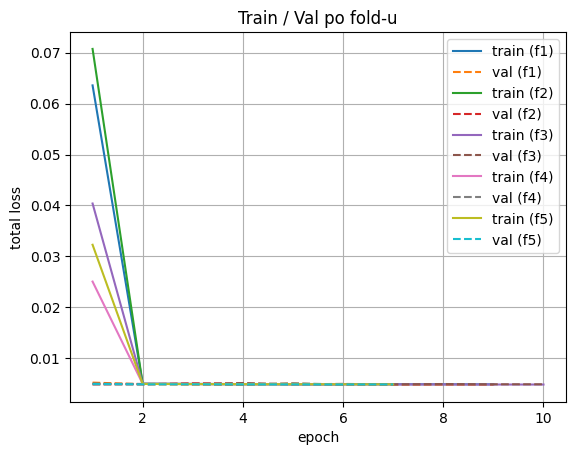

In [178]:
import matplotlib.pyplot as plt

for f, g in hist_df.groupby("fold"):
    plt.plot(g["epoch"], g["train_total"], label=f"train (f{f})")
    plt.plot(g["epoch"], g["val_total"],   label=f"val (f{f})", linestyle="--")

plt.xlabel("epoch");  plt.ylabel("total loss")
plt.title("Train / Val po fold-u")
plt.legend();  plt.grid(True);  plt.show()


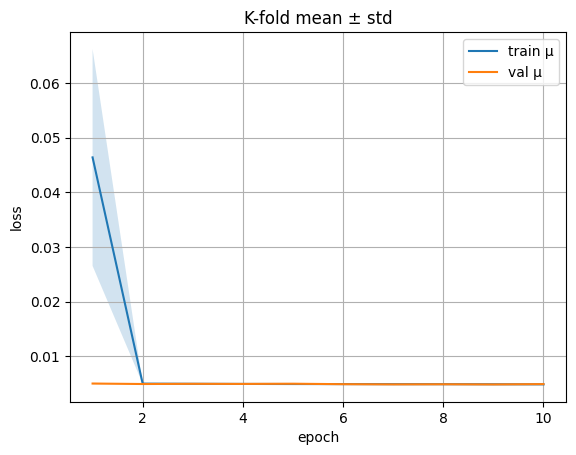

In [179]:
import numpy as np

pivot_tr = hist_df.pivot(index="epoch", columns="fold", values="train_total")
pivot_va = hist_df.pivot(index="epoch", columns="fold", values="val_total")

μ_tr, σ_tr = pivot_tr.mean(axis=1), pivot_tr.std(axis=1)
μ_va, σ_va = pivot_va.mean(axis=1), pivot_va.std(axis=1)

plt.plot(μ_tr.index, μ_tr, label="train μ")
plt.fill_between(μ_tr.index, μ_tr-σ_tr, μ_tr+σ_tr, alpha=0.2)

plt.plot(μ_va.index, μ_va, label="val μ")
plt.fill_between(μ_va.index, μ_va-σ_va, μ_va+σ_va, alpha=0.2)

plt.xlabel("epoch");  plt.ylabel("loss")
plt.title("K-fold mean ± std")
plt.legend();  plt.grid(True);  plt.show()


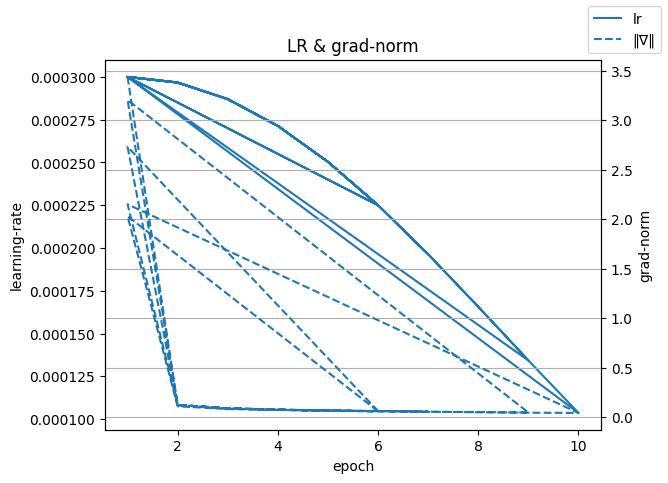

In [180]:
fig, ax1 = plt.subplots()

ax1.plot(hist_df["epoch"], hist_df["lr"],  label="lr")
ax1.set_xlabel("epoch");  ax1.set_ylabel("learning-rate")

ax2 = ax1.twinx()
ax2.plot(hist_df["epoch"], hist_df["grad_norm"], label="‖∇‖", linestyle="--")
ax2.set_ylabel("grad-norm")

fig.legend(loc="upper right");  plt.title("LR & grad-norm");  plt.grid(True);  plt.show()


In [ ]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error
import re

def plot_prediction_vs_truth(df, model, hidden_layers, neurons_per_layer, start_time=0, end_time=0.1,phases_to_display=[0, 1, 2]):
    #model = FeedforwardNet(input_size=10, hidden_layers=6, neurons_per_layer=64).to(device)

    pth_path = f"1ph_inv_model_h{hidden_layers}w{neurons_per_layer}_more_data.pth"
    if not os.path.isfile(pth_path):
        print(f"⚠️ Skip: Missing model file {pth_path}")
    
    model.load_state_dict(torch.load(pth_path))
    model.eval()


    match = re.search(r"L=(?P<L>[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)", df)
    if match:
        L_val = float(match.group("L"))
    else:
        L_val = None  # or fallback value

    # === Load Dataset ===
    df = pd.read_csv(df)
    top = df["top"].values
    bot = df["bot"].values

    # === Prepare Input ===
    X_all = df[["value", "top", "bot", "time_step", "L_value"]].values.astype(np.float32)
    y_true_all = df[["next_value"]].values.astype(np.float32)
    next_time = df["time"].values + df["time_step"].values

    # === Denormalize ===
    scaler_X, scaler_y = dataset.get_scalers()
    y_true_denorm = y_true_all
    X_tensor = torch.tensor(X_all, dtype=torch.float32).to(device)

    with torch.no_grad():
        y_pred_tensor = model(X_tensor).cpu().numpy()
    y_pred_denorm = y_pred_tensor

    # === Time Window ===

    mask = (next_time >= start_time) & (next_time <= end_time)

    # === MAE Calculation ===
    mae_Ia = mean_absolute_error(y_true_denorm[mask, 0], y_pred_denorm[mask, 0])

    # === Plot Config ===
    fig, ax1 = plt.subplots(figsize=(14, 6))


    # === Leva osa: True (deblje) i Pred (tanke)
    
    ax1.plot(next_time[mask], y_true_denorm[mask], color='teal', linewidth=2, label="True" )
    ax1.plot(next_time[mask], y_pred_denorm[mask], color='coral', linewidth=1, label="Pred" )
    '''ax1.plot(next_time[mask], top[mask], color="red", linewidth=0.5, label="sw states" )
    ax1.scatter(next_time[mask], top[mask], color="red", linewidth=0.5, label="sw states" )
    ax1.plot(next_time[mask], bot[mask], color='blue', linewidth=0.5, label="sw states" )
    ax1.scatter(next_time[mask], bot[mask], color="blue", linewidth=0.5, label="sw states" )'''
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Current (A)")
    ax1.grid(True)

    # === Desna osa: Error
    ax2 = ax1.twinx()
    
    error = -np.abs(y_true_denorm[mask] - y_pred_denorm[mask])
    ax2.plot(next_time[mask], error, color='red', linestyle="--", linewidth=1.5, label="Error" )

    ax2.set_ylabel("−|Error| (A)", color = "red")
    #ax2.invert_yaxis()  # Nula na vrhu

    # === Naslov & Legenda
    plt.title(f"Prediction vs GT (1 Phase) | {start_time:.3f}s–{end_time:.3f}s | MAE: Ia={mae_Ia:.4f} | Inductanse: L={L_val:.7f}")

    # Samo po jednom labela u legendi
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper center", ncol=3)

    plt.tight_layout()
    
    #return fig

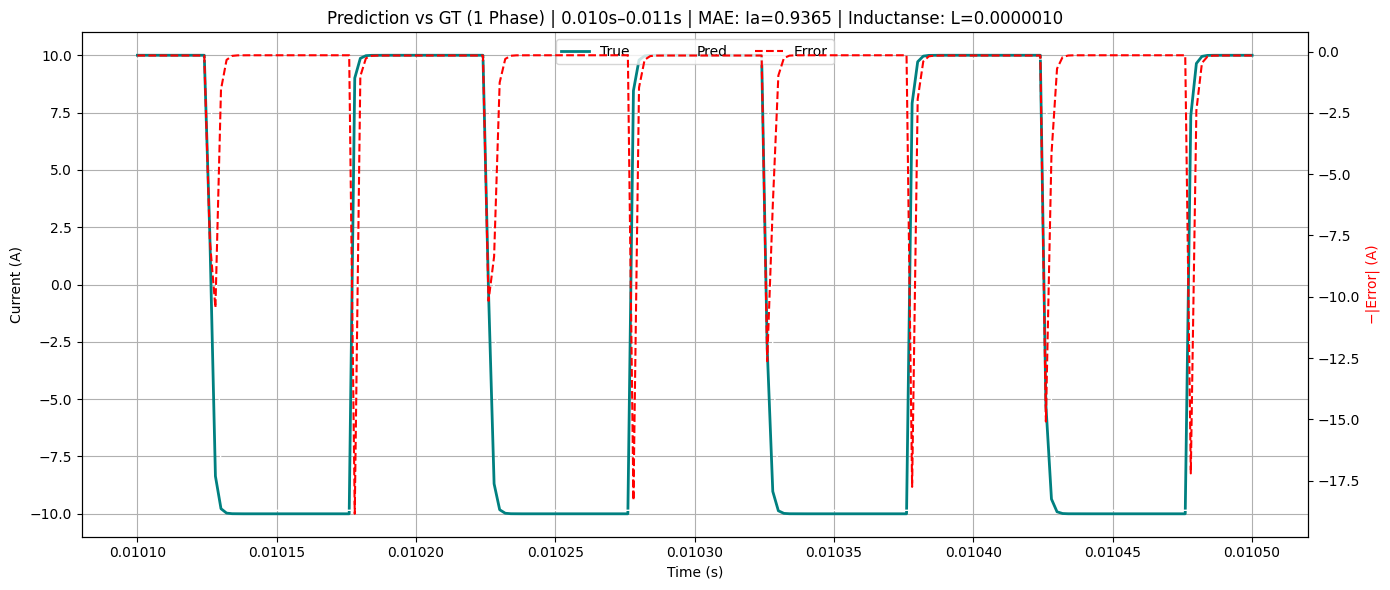

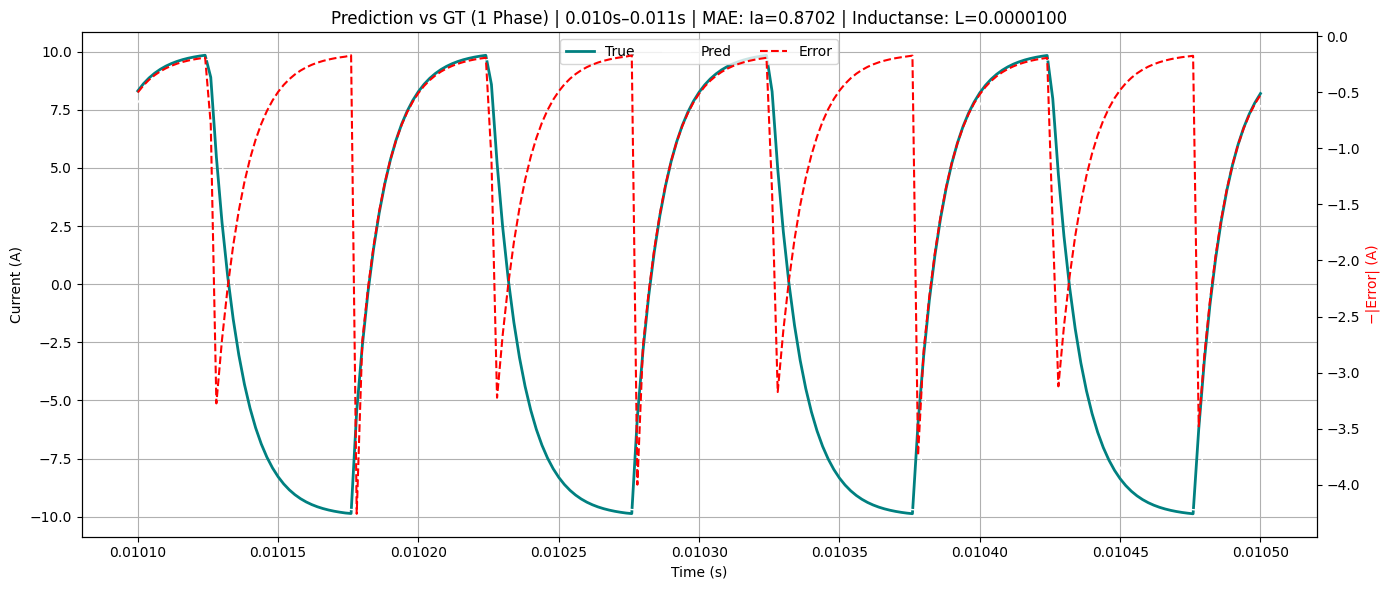

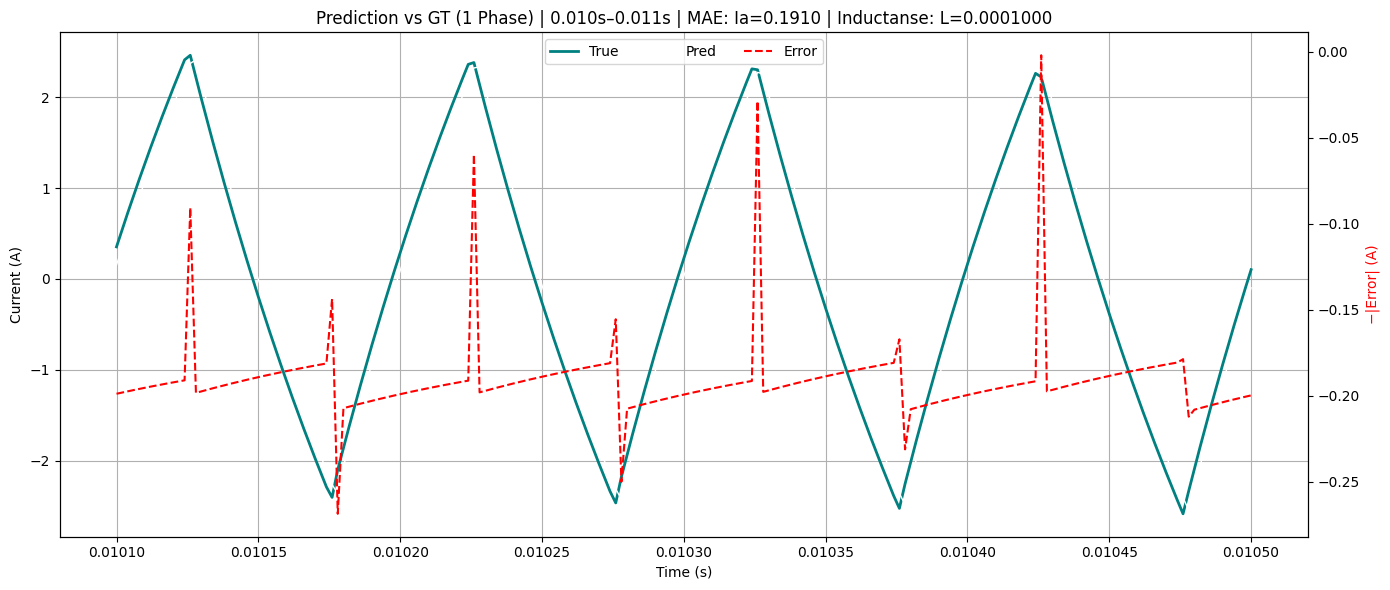

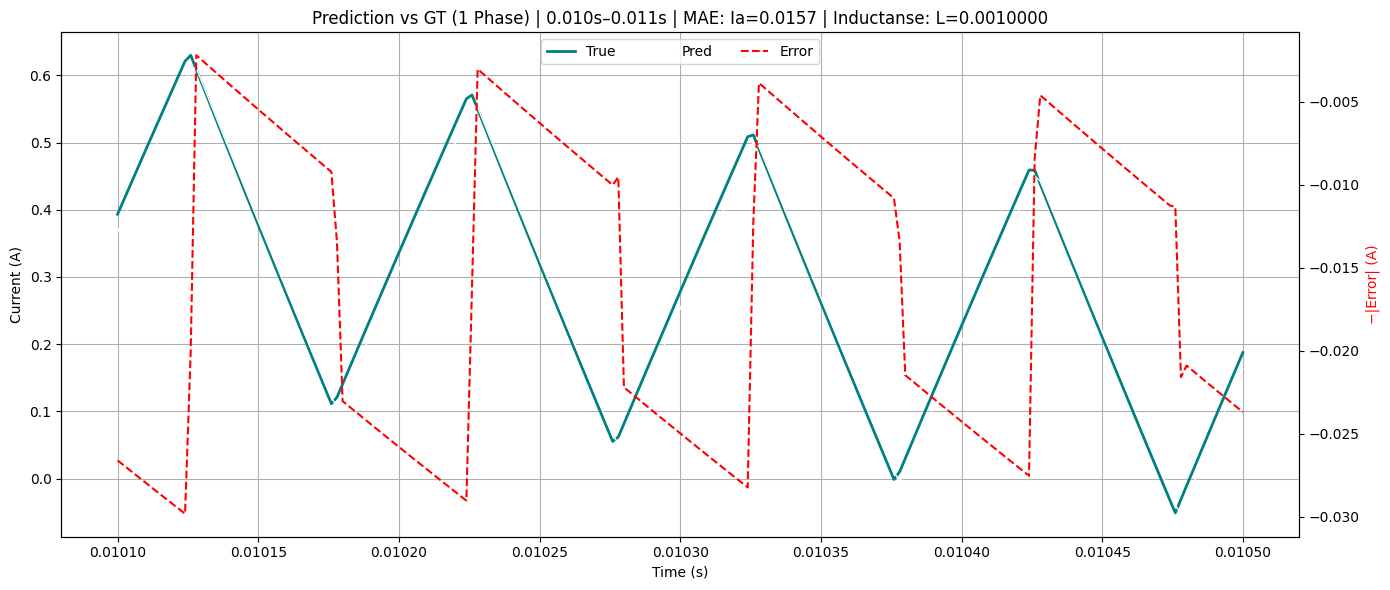

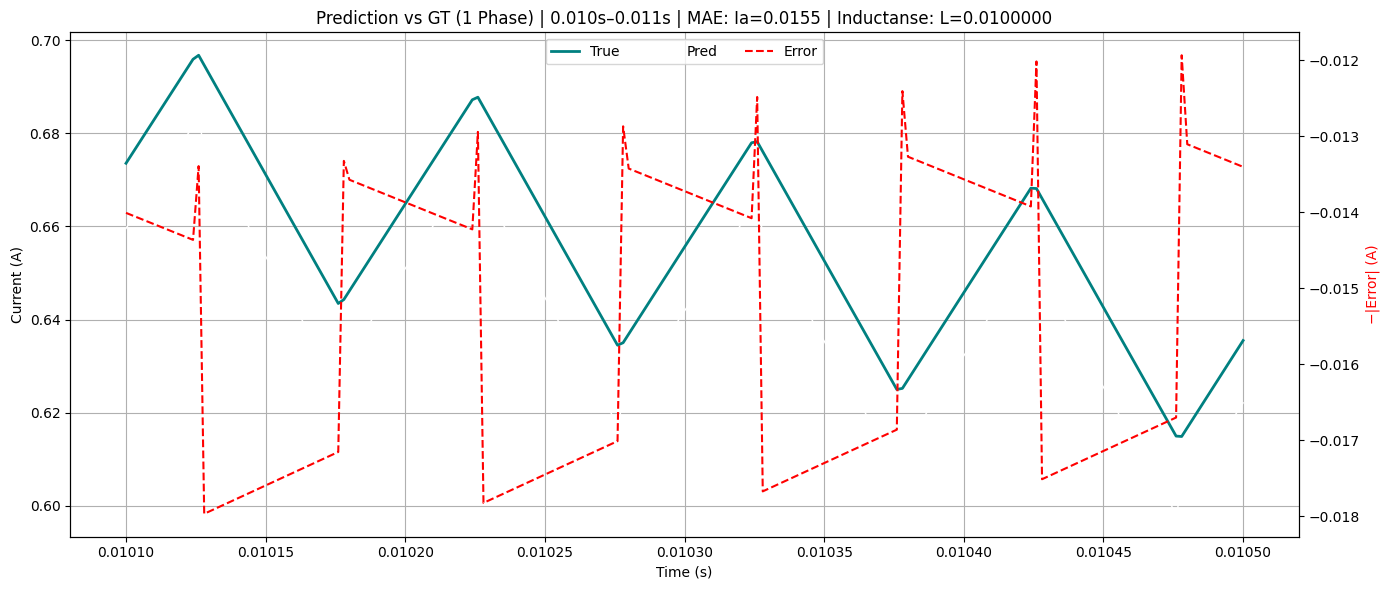

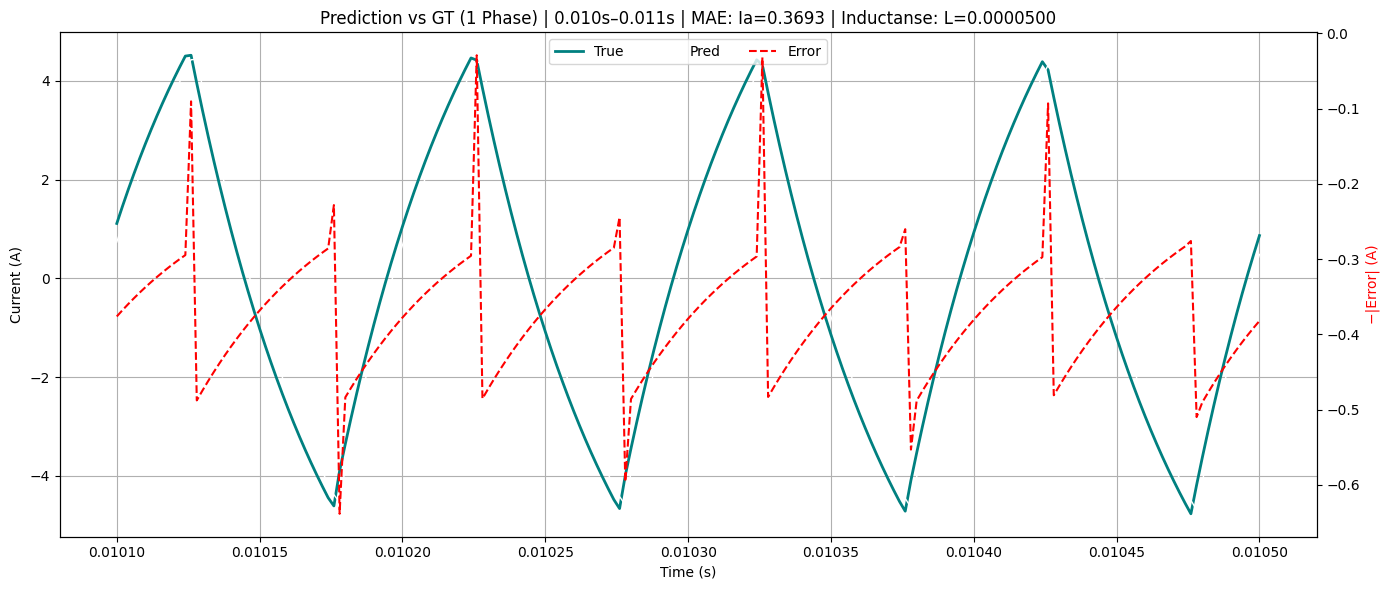

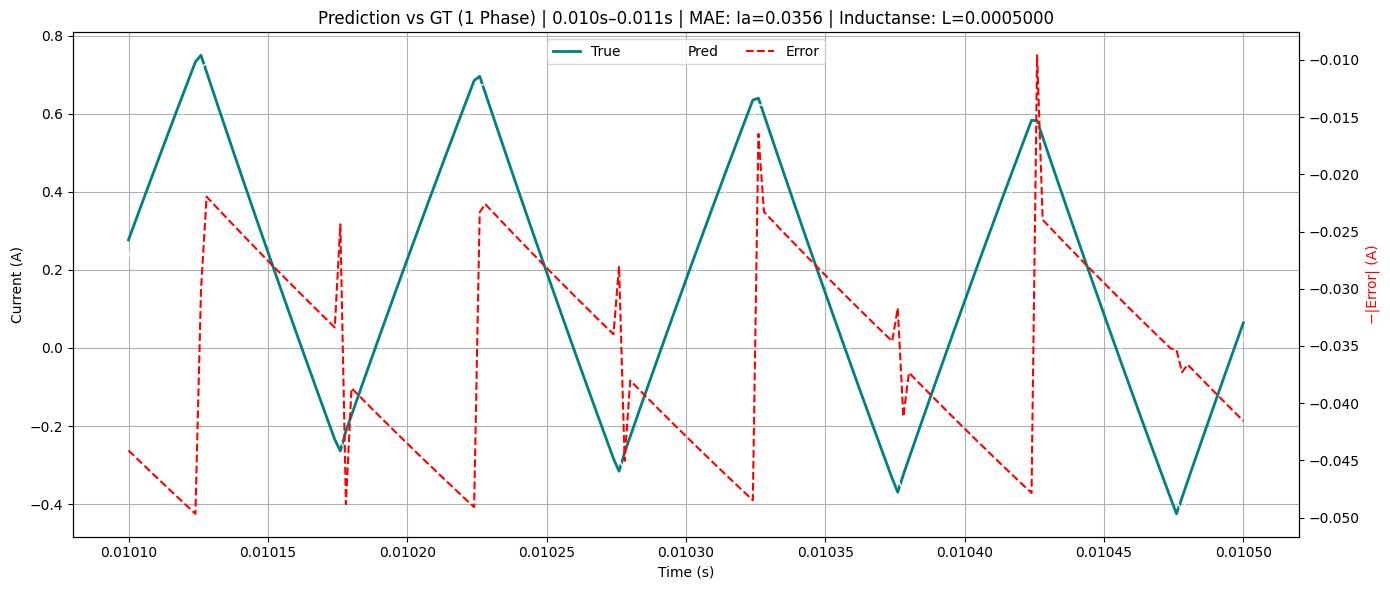

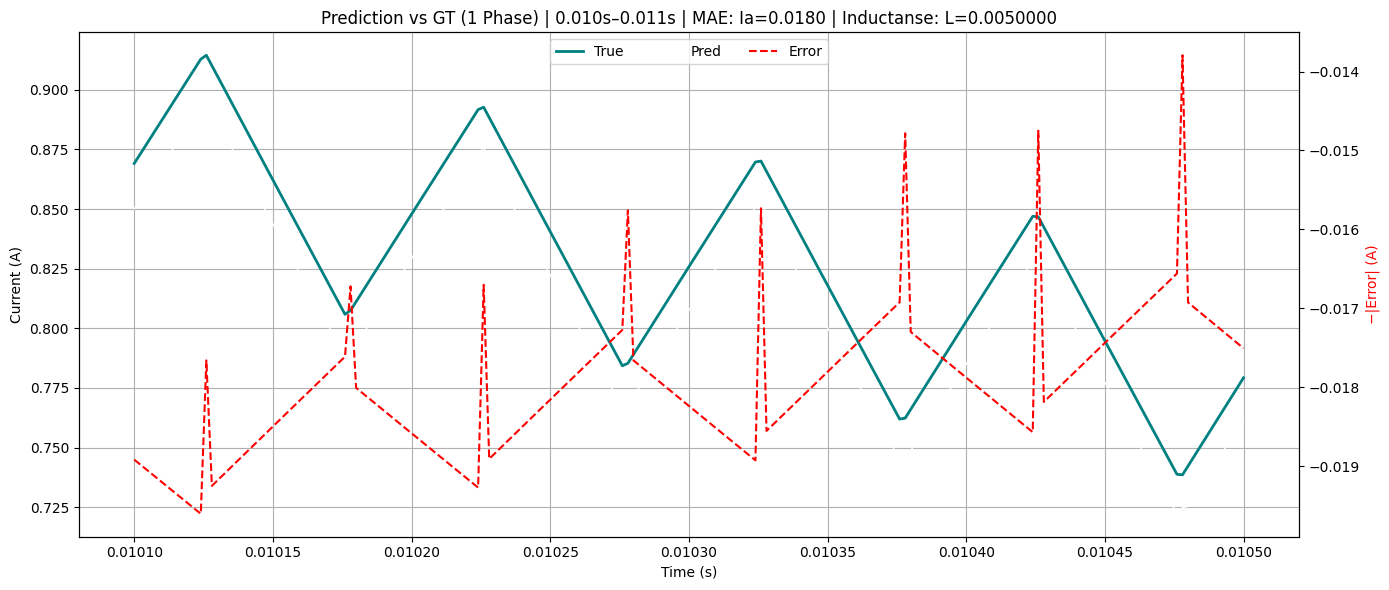

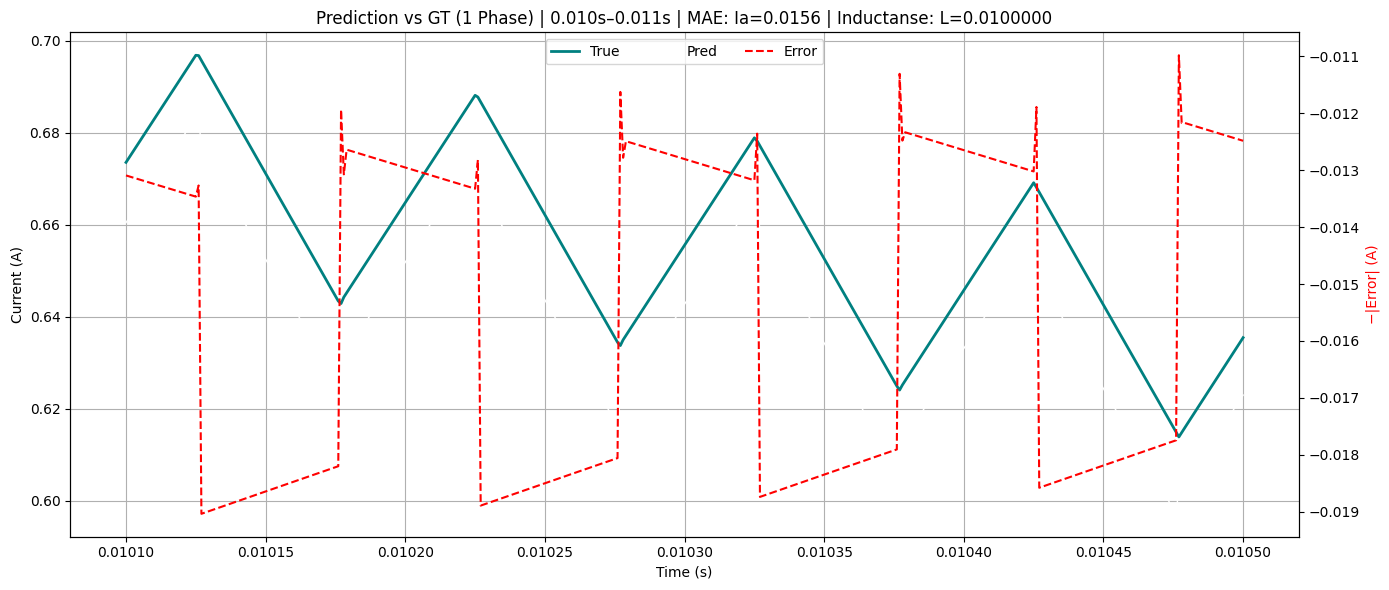

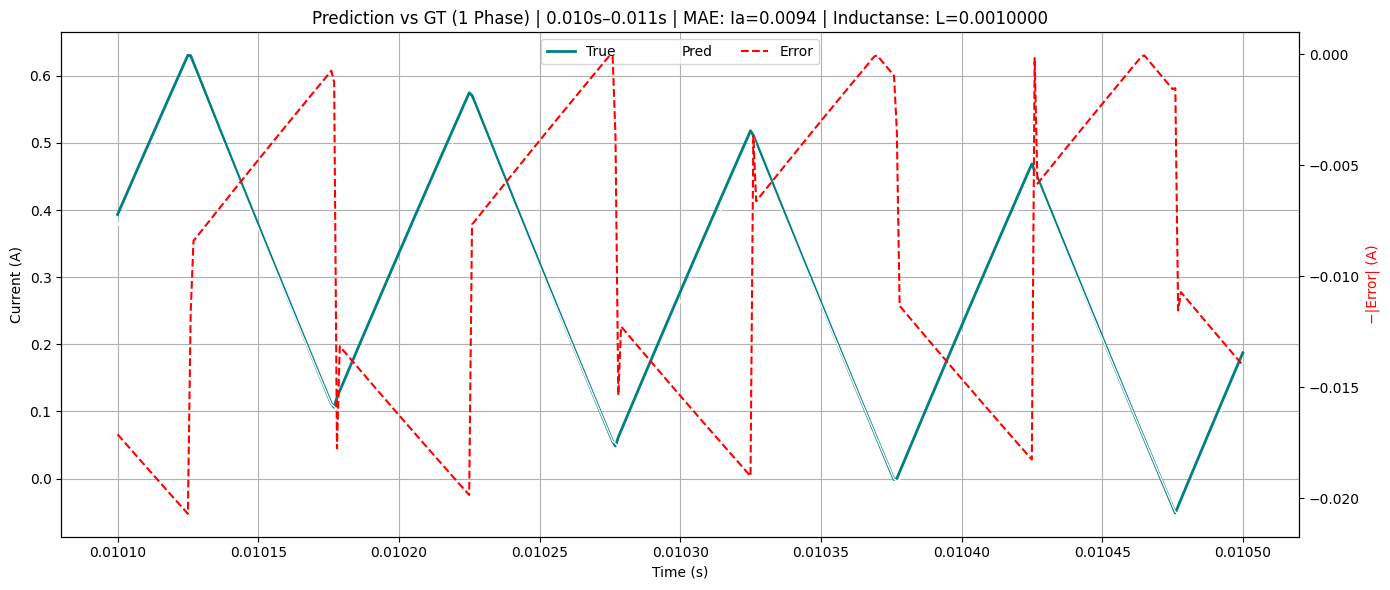

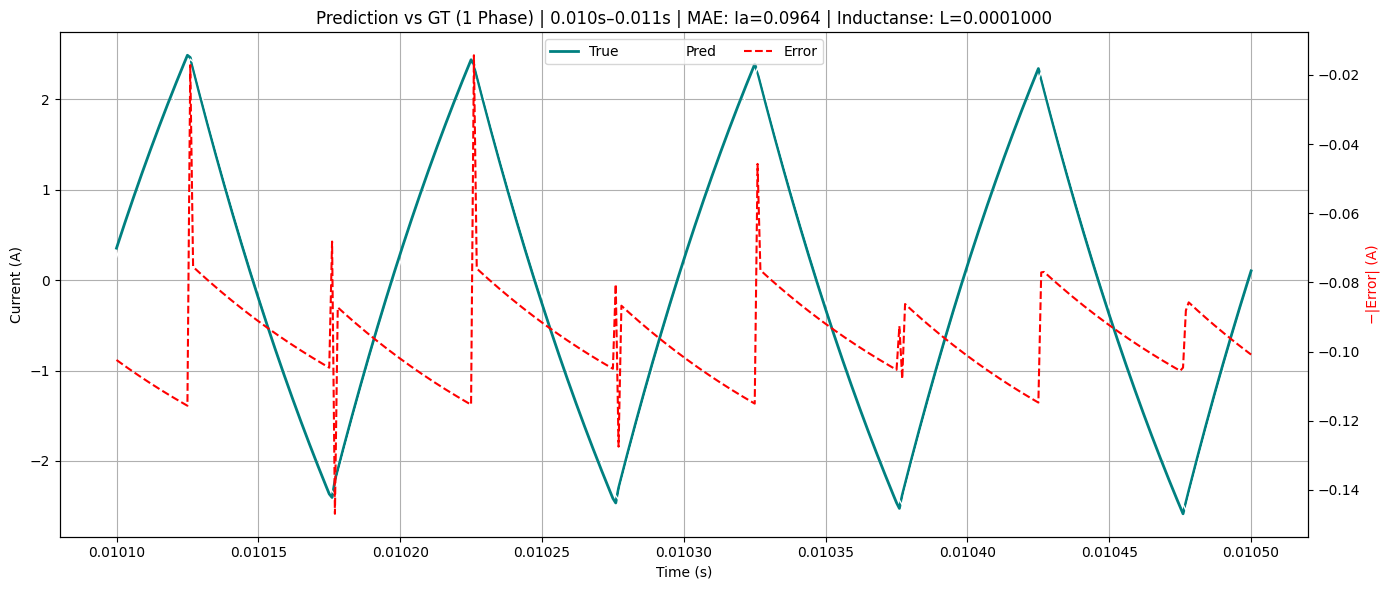

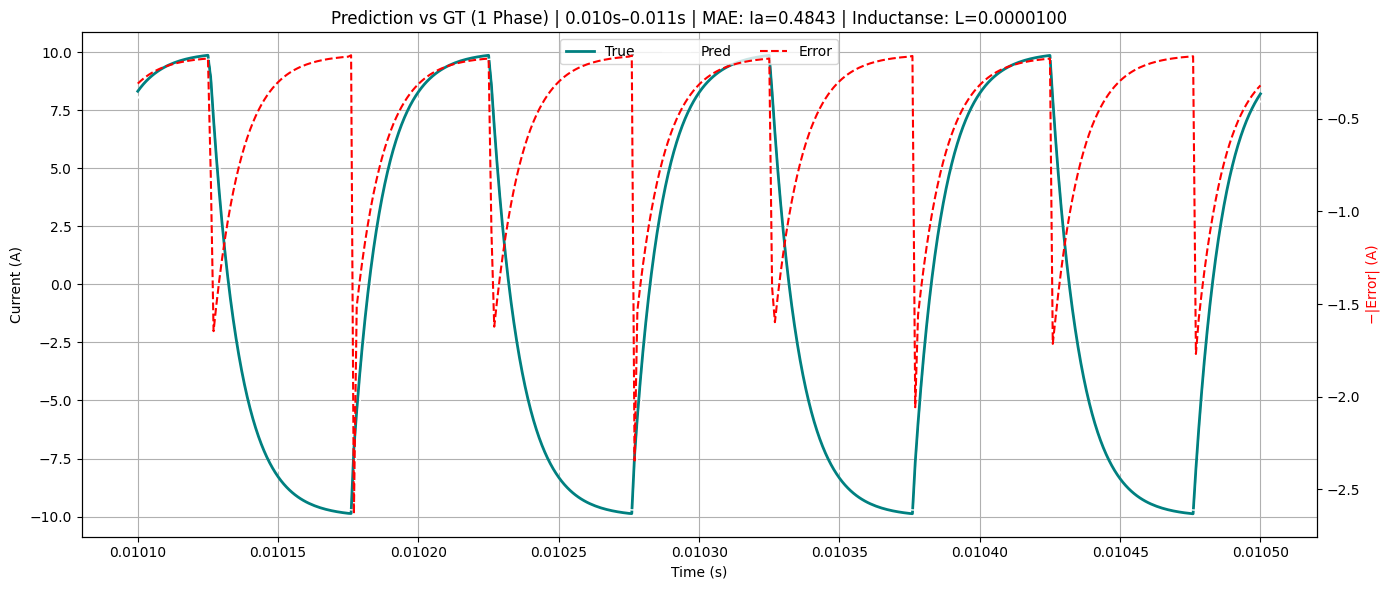

In [182]:
start_time = 0.0101
end_time   = 0.01050

val_file_paths = [
    "new_igbt_leg_L=1e-6_time_step_2e-6.csv",
    "new_igbt_leg_L=1e-5_time_step_2e-6.csv",
    "new_igbt_leg_L=1e-4_time_step_2e-6.csv",
    "new_igbt_leg_L=1e-3_time_step_2e-6.csv",
    "new_igbt_leg_L=1e-2_time_step_2e-6.csv",
    "new_igbt_leg_L=5e-5_time_step_2e-6.csv",
    "new_igbt_leg_L=5e-4_time_step_2e-6.csv",
    "new_igbt_leg_L=5e-3_time_step_2e-6.csv",
]



for f in val_file_paths:
    plot_prediction_vs_truth(df = f,
                             start_time=start_time,
                             end_time=end_time,
                             model=model, 
                             hidden_layers=hidden_layers, 
                             neurons_per_layer=neurons_per_layer
                            )


test_file_paths = [  'new_igbt_leg_L=1e-2_time_step_1e-6.csv', 
                'new_igbt_leg_L=1e-3_time_step_1e-6.csv', 
                'new_igbt_leg_L=1e-4_time_step_1e-6.csv', 
                'new_igbt_leg_L=1e-5_time_step_1e-6.csv']

for f in test_file_paths:
    plot_prediction_vs_truth(df = f,
                             start_time=start_time,
                             end_time=end_time,
                             model=model, 
                             hidden_layers=hidden_layers, 
                             neurons_per_layer=neurons_per_layer
                            )

In [183]:
def rolling_mean(arr, window=250):
    """Simple moving average."""
    return np.convolve(arr, np.ones(window)/window, mode='same')


In [184]:
def plot_prediction_vs_truth_1model_multi_phase(
    csv_path,
    model,
    name,
    scaler_X,
    scaler_y,
    hidden_layers,
    neurons_per_layer,
    start_time,
    end_time,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    phases_to_display = [0, 1, 2],
    smooth = False,
    window_size = 200
):
   
    model.load_state_dict(torch.load(name, map_location=device))
    model.to(device)
    model.eval()

    match = re.search(r"L=(?P<L>[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)", csv_path)
    if match:
        L_val = float(match.group("L"))
    else:
        L_val = None  # or fallback value
  
    df = pd.read_csv(csv_path)

    # === Izvlaci ulaze po fazi ===
    inputs_per_phase = {
        0: df[['Ia', 'topA', 'botA', 'time_step', "La_value"]].values.astype(np.float32),
        1: df[['Ib', 'topB', 'botB', 'time_step', "Lb_value"]].values.astype(np.float32),
        2: df[['Ic', 'topC', 'botC', 'time_step', "Lc_value"]].values.astype(np.float32),
    }

    targets = df[['Ia_next_value', 'Ib_next_value', 'Ic_next_value']].values.astype(np.float32)
    next_time = df["time"].values + df["time_step"].values

    # === Predikcije za svaku fazu ===
    preds = []
    for i in phases_to_display:
        X = inputs_per_phase[i]
        X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
        with torch.no_grad():
            y_pred = model(X_tensor).cpu().numpy()
        y_pred_denorm = y_pred
        preds.append(y_pred_denorm)

    # === Kombinuj predikcije u jedan array
    y_pred_denorm_all = np.concatenate(preds, axis=1)
    y_true_denorm = targets  # već je neskalirano

    # === Time Window
    
    mask = (next_time >= start_time) & (next_time <= end_time)

    # === MAE po fazi

    mae_values = []

    for idx, i in enumerate(phases_to_display):
        mae_i = mean_absolute_error(y_true_denorm[mask, i], y_pred_denorm_all[mask, idx])
        mae_values.append(mae_i)


    # === Plot
    fig, ax1 = plt.subplots(figsize=(14, 6))
    phase_colors = ["teal", "orange", "seagreen"]
    truth_colors =  ["purple", "red", "pink"]

    if not smooth:
        for idx, i in enumerate(phases_to_display):
            ax1.plot(next_time[mask], y_true_denorm[mask, i], color=truth_colors[i], alpha=0.7, linewidth=2, label=f"True Phase {i+1}")
            ax1.plot(next_time[mask], y_pred_denorm_all[mask, idx], color=phase_colors[i], linestyle='--', linewidth=1, label=f"Pred {i+1}")
    else: 
        for idx, i in enumerate(phases_to_display):
            # Smooth signals using rolling mean
            y_true_smooth = rolling_mean(y_true_denorm[mask, i], window= 200)
            y_pred_smooth = rolling_mean(y_pred_denorm_all[mask, idx], window=200)

            ax1.plot(next_time[mask], y_true_smooth, color=truth_colors[i], alpha=0.8, linewidth=2, label=f"True Phase {i+1} - Smoothed")
            ax1.plot(next_time[mask], y_pred_smooth, color=phase_colors[i], linestyle='--', linewidth=2, label=f"Pred {i+1} - Smoothed")
            '''ax1.plot(next_time[mask], y_true_denorm[mask, i], color="maroon", alpha=1, linewidth=0.7, label=f"True Phase {i+1}")
            ax1.plot(next_time[mask], y_pred_denorm_all[mask, idx], color="coral", linestyle='--', linewidth=0.4, label=f"Pred {i+1}")'''



    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Current (A)")
    ax1.grid(True)

    # === Greška sa desne strane
    ax2 = ax1.twinx()
    error_colors = ["teal", "orange", "seagreen"]
    if not smooth:
        for idx, i in enumerate(phases_to_display):
            err = -np.abs(y_true_denorm[mask, i] - y_pred_denorm_all[mask, idx])
            ax2.plot(next_time[mask], err, color=error_colors[i], linestyle="--", alpha=0.4, linewidth=1)
    else:
        for idx, i in enumerate(phases_to_display):
            err = -np.abs(y_true_denorm[mask, i] - y_pred_denorm_all[mask, idx])
            err_smooth = rolling_mean(err,  window=200)
            ax2.plot(next_time[mask], err_smooth, color=error_colors[i], linestyle="--", alpha=0.4, linewidth=1)



    ax2.set_ylabel("−|Error| (A)")
    #ax2.invert_yaxis()  # nula na vrhu

    mae_text = ", ".join([f"I{chr(97+i)}={mae:.4f}" for i, mae in zip(phases_to_display, mae_values)])
    plt.title(f"Prediction per phase vs GT | MAE: {mae_text},  L={L_val}")


    lines1, labels1 = ax1.get_legend_handles_labels()
    ax1.legend(lines1, labels1, loc="upper center", ncol=3)

    plt.tight_layout()
    #return fig

In [185]:
print(hidden_layers)
hidden_layers = 7

7


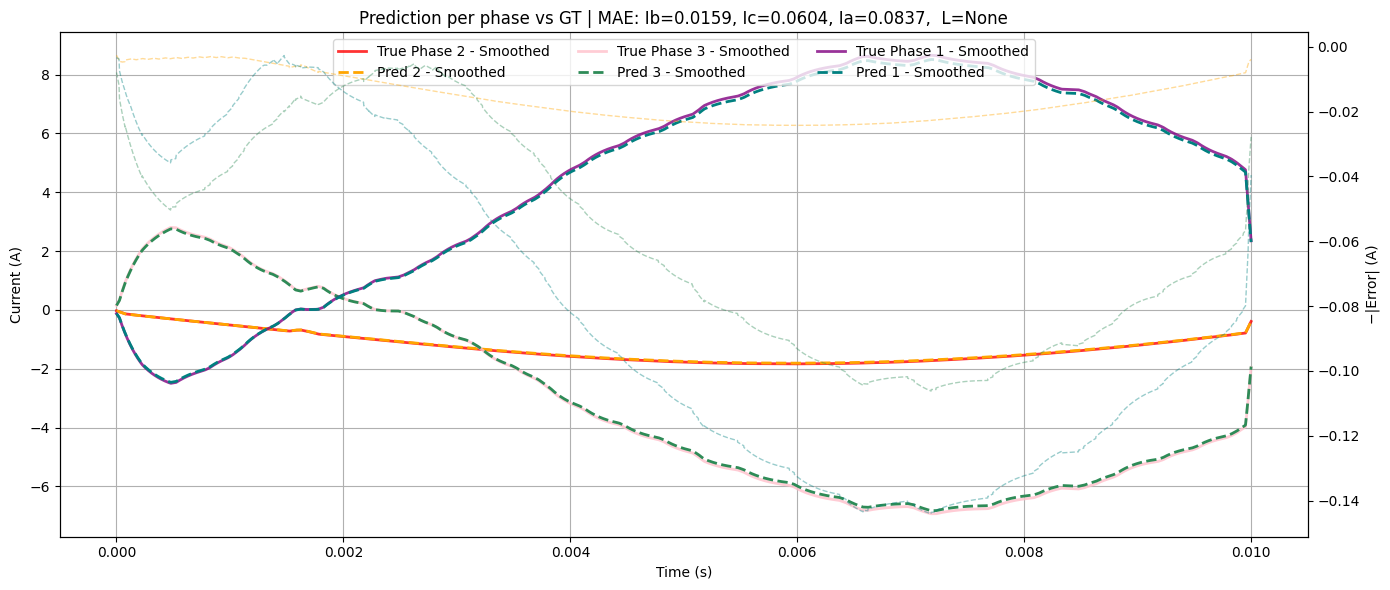

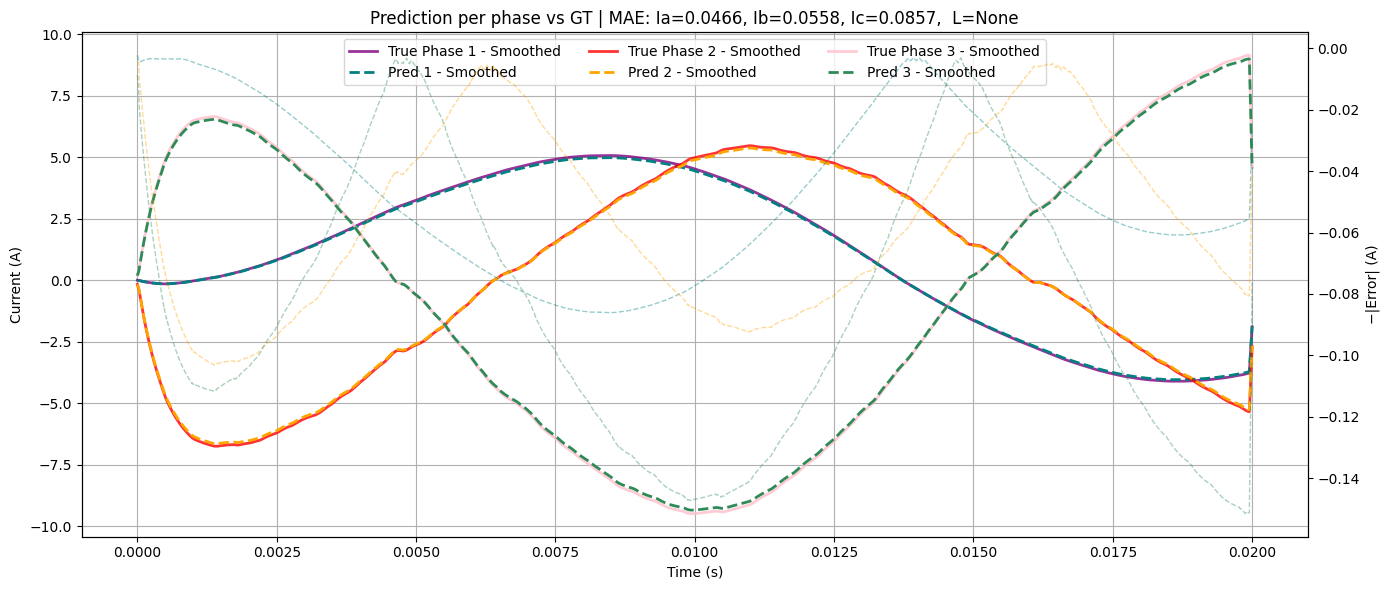

In [186]:
plot_prediction_vs_truth_1model_multi_phase(model = FeedforwardNet(hidden_layers=hidden_layers, 
                                            neurons_per_layer=neurons_per_layer),
                                            name="1ph_inv_model_h7w64_more_data.pth", 
                                            csv_path='new_3_ph_igbt_leg_La=5e-4_Lb=3e-2_Lc=4e-6_time_step_5e-7.csv', 
                                            scaler_X=dataset.scaler_X, 
                                            scaler_y=dataset.scaler_y, 
                                            hidden_layers=hidden_layers, 
                                            neurons_per_layer=64,
                                            start_time = 0.0,
                                            end_time = 0.01,
                                            phases_to_display=[1, 2, 0],
                                            smooth = True,
                                            window_size = 10
                                            ) 
plot_prediction_vs_truth_1model_multi_phase(model = FeedforwardNet(hidden_layers=hidden_layers, 
                                            neurons_per_layer=neurons_per_layer),
                                            name="1ph_inv_model_h7w64_more_data.pth", 
                                            csv_path='new_3_ph_igbt_leg_La=1e-2_Lb=1e-3_Lc=1e-5_time_step_5e-7.csv', 
                                            scaler_X=dataset.scaler_X, 
                                            scaler_y=dataset.scaler_y, 
                                            hidden_layers=hidden_layers, 
                                            neurons_per_layer=64,
                                            start_time = 0.000,
                                            end_time = 0.02,
                                            phases_to_display=[0,1,2],
                                            smooth = True, 
                                            window_size = 10
                                            )

In [187]:
'''import torch
from itertools import product

# Define lists of architectures to test
hidden_layers_list = [9, 11]
neurons_per_layer_list = [64, 96, 128]

# Loop through all combinations
for hidden_layers, neurons_per_layer in product(hidden_layers_list, neurons_per_layer_list):
    print(f"\n🧪 Testing architecture: {hidden_layers} hidden layers, {neurons_per_layer} neurons per layer")

    # Train and validate model
    best_model_state_dict, test_set, train_losses, val_losses, model = cross_validate(
        dataset,
        input_size=input_size,
        hidden_layers=hidden_layers,
        neurons_per_layer=neurons_per_layer
    )

    # Load the best weights into the model
    model.load_state_dict(best_model_state_dict)

    # Save the model
    name = f"1ph_inv_model_h{hidden_layers}w{neurons_per_layer}.pth"
    torch.save(model.state_dict(), name)
    print(f"✅ Model saved as '{name}'")
'''

'import torch\nfrom itertools import product\n\n# Define lists of architectures to test\nhidden_layers_list = [9, 11]\nneurons_per_layer_list = [64, 96, 128]\n\n# Loop through all combinations\nfor hidden_layers, neurons_per_layer in product(hidden_layers_list, neurons_per_layer_list):\n    print(f"\n🧪 Testing architecture: {hidden_layers} hidden layers, {neurons_per_layer} neurons per layer")\n\n    # Train and validate model\n    best_model_state_dict, test_set, train_losses, val_losses, model = cross_validate(\n        dataset,\n        input_size=input_size,\n        hidden_layers=hidden_layers,\n        neurons_per_layer=neurons_per_layer\n    )\n\n    # Load the best weights into the model\n    model.load_state_dict(best_model_state_dict)\n\n    # Save the model\n    name = f"1ph_inv_model_h{hidden_layers}w{neurons_per_layer}.pth"\n    torch.save(model.state_dict(), name)\n    print(f"✅ Model saved as \'{name}\'")\n'

In [188]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.metrics import mean_absolute_error
from itertools import product

def compare_models_on_file(csv_file, input_size, output_size, model_class,
                           hidden_layers_list, neurons_list,
                           start_time=None, end_time=None):
    # Učitavanje CSV fajla

    match = re.search(r"L=(?P<L>[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)", csv_file)
    if match:
        L_val = float(match.group("L"))
    else:
        L_val = None  # or fallback value
    df = pd.read_csv(csv_file)

    # Ako je definisan vremenski prozor, filtriraj po 'time' koloni
    if start_time is not None and end_time is not None:
        time_mask = (df['time'] >= start_time) & (df['time'] <= end_time)
        df = df[time_mask]

    # Izvuci ulazne i izlazne kolone
    X = df[['value', 'top', 'bot', 'time_step', 'L_value']].values.astype('float32')
    y_true = df['next_value'].values.astype('float32')
    time = df['time'].values  # za X osu

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    X_tensor = torch.tensor(X, dtype=torch.float32).to(device)

    # Plotuj Ground Truth
    plt.figure(figsize=(12, 6))
    plt.plot(time, y_true, label='Ground Truth', color='black', linewidth=4, alpha=0.6)

    # Prolazak kroz sve kombinacije arhitektura
    for hidden_layers, neurons_per_layer in product(hidden_layers_list, neurons_list):
        model_filename = f"1ph_inv_model_h{hidden_layers}w{neurons_per_layer}.pth"
        if not os.path.isfile(model_filename):
            print(f"⚠️ Model not found: {model_filename}")
            continue

        # Inicijalizacija i učitavanje modela
        model = model_class(input_size=input_size, hidden_layers=hidden_layers,
                            neurons_per_layer=neurons_per_layer, output_size=output_size).to(device)
        model.load_state_dict(torch.load(model_filename, map_location=device))
        model.eval()

        with torch.no_grad():
            y_pred = model(X_tensor).cpu().numpy().squeeze()

        mae = mean_absolute_error(y_true, y_pred)
        plt.plot(time, y_pred, label=f"h={hidden_layers}, w={neurons_per_layer} | MAE={mae:.4f} ", linestyle="--")

    plt.title(f"Model Predictions vs Ground Truth | L = {L_val}")
    plt.xlabel("Time (s)")
    plt.ylabel("next_value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [191]:
'''hidden_layers_list = [7, 9, 11]
neurons_list = [96, 64, 128]  # Mora da se poklapa dužinom sa gornjom listom

for f in file_names:
    compare_models_on_file(
        csv_file=f,
        input_size=5,
        output_size=1,
        hidden_layers_list=hidden_layers_list,
        neurons_list=neurons_list,
        model_class=FeedforwardNet,
        start_time=0.0,
        end_time=0.01
    )'''


'hidden_layers_list = [7, 9, 11]\nneurons_list = [96, 64, 128]  # Mora da se poklapa dužinom sa gornjom listom\n\nfor f in file_names:\n    compare_models_on_file(\n        csv_file=f,\n        input_size=5,\n        output_size=1,\n        hidden_layers_list=hidden_layers_list,\n        neurons_list=neurons_list,\n        model_class=FeedforwardNet,\n        start_time=0.0,\n        end_time=0.01\n    )'

In [194]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

def analyze_dI_dt_distribution(csv_paths, value_col="value", dt_col="time_step", plot=True):
    all_dI_dt = []

    for path in csv_paths:
        df = pd.read_csv(path)
        if value_col not in df.columns or dt_col not in df.columns:
            print(f"⚠️ Skip: '{path}' does not contain required columns.")
            continue

        I = df[value_col].values
        dt = df[dt_col].values

        # ΔI / Δt, skip first since diff shortens array by 1
        dI = np.diff(I)
        dT = dt[1:]  # align with diff(I)
        dI_dt = dI / dT
        all_dI_dt.append(dI_dt)

    # Concatenate all
    all_dI_dt = np.concatenate(all_dI_dt)

    # Stats
    d_min = np.min(all_dI_dt)
    d_max = np.max(all_dI_dt)
    p01 = np.percentile(all_dI_dt, 5)
    p99 = np.percentile(all_dI_dt, 95)
    mean = np.mean(all_dI_dt)
    std = np.std(all_dI_dt)

    print(f"min: {d_min:.2e}")
    print(f"max: {d_max:.2e}")
    print(f"1%% - 99%% percentiles: {p01:.2e} to {p99:.2e}")
    print(f"mean ± std: {mean:.2e} ± {std:.2e}")

    # Plot
    if plot:
        plt.figure(figsize=(6, 5))
        plt.hist(all_dI_dt, bins=500, log=True)
        plt.title("Distribution of real dI/dt")
        plt.xlabel("dI/dt (A/s)")
        plt.ylabel("Frequency (log scale)")
        plt.grid(True)
        plt.show()

    return {
        "min": d_min,
        "max": d_max,
        "p01": p01,
        "p99": p99,
        "mean": mean,
        "std": std
    }


In [196]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
import re

def rolling_mean(arr, window=200):
    return np.convolve(arr, np.ones(window) / window, mode='same')

def plot_prediction_vs_truth_1model_multi_phase(
    csv_path,
    model,
    name,
    scaler_X,
    scaler_y,
    hidden_layers,
    neurons_per_layer,
    start_time,
    end_time,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    phases_to_display=[0, 1, 2],
    smooth=True,
    window_size=200,
    save_path="prediction_vs_truth_highres.png"
):
    model.load_state_dict(torch.load(name, map_location=device))
    model.to(device)
    model.eval()

    match_all = re.findall(r"L([abc])=([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)", csv_path)
    L_values = {key: float(val) for key, val in match_all}
    L_text = ", ".join([f"L{key}={L_values.get(key, 'NA'):.0e}" for key in ['a', 'b', 'c']])


    df = pd.read_csv(csv_path)

    inputs_per_phase = {
        0: df[['Ia', 'topA', 'botA', 'time_step', "La_value"]].values.astype(np.float32),
        1: df[['Ib', 'topB', 'botB', 'time_step', "Lb_value"]].values.astype(np.float32),
        2: df[['Ic', 'topC', 'botC', 'time_step', "Lc_value"]].values.astype(np.float32),
    }

    targets = df[['Ia_next_value', 'Ib_next_value', 'Ic_next_value']].values.astype(np.float32)
    next_time = df["time"].values + df["time_step"].values

    preds = []
    for i in phases_to_display:
        X = inputs_per_phase[i]
        X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
        with torch.no_grad():
            y_pred = model(X_tensor).cpu().numpy()
        preds.append(y_pred)

    y_pred_all = np.concatenate(preds, axis=1)
    y_true_all = targets

    mask = (next_time >= start_time) & (next_time <= end_time)
    plt.style.use("dark_background")
    fig, ax1 = plt.subplots(figsize=(16, 8))
    phase_colors = ["teal", "darkorange", "seagreen"]
    truth_colors = ["indigo", "firebrick", "hotpink"]

    mae_texts = []
    for idx, phase in enumerate(phases_to_display):
        true_vals = y_true_all[mask, phase]
        pred_vals = y_pred_all[mask, idx]
        mae = mean_absolute_error(true_vals, pred_vals)
        mae_texts.append(f"I{chr(97 + phase)}={mae:.4f}")

        if smooth:
            true_vals = rolling_mean(true_vals, window=window_size)
            pred_vals = rolling_mean(pred_vals, window=window_size)

        ax1.plot(next_time[mask], true_vals, color=truth_colors[phase], linewidth=2, label=f"True Phase {phase + 1}")

    for idx, phase in enumerate(phases_to_display):
        true_vals = y_true_all[mask, phase]
        pred_vals = y_pred_all[mask, idx]
        mae = mean_absolute_error(true_vals, pred_vals)
        mae_texts.append(f"I{chr(97 + phase)}={mae:.4f}")

        if smooth:
            true_vals = rolling_mean(true_vals, window=window_size)
            pred_vals = rolling_mean(pred_vals, window=window_size)

        ax1.plot(next_time[mask], pred_vals, color=phase_colors[phase], linestyle='--', linewidth=2, label=f"Pred {phase + 1}")

    ax1.set_xlabel("Time (s)", fontsize=14)
    ax1.set_ylabel("Current (A)", fontsize=14)
    ax1.grid(True)

    ax2 = ax1.twinx()
    for idx, phase in enumerate(phases_to_display):
        err = -np.abs(y_true_all[mask, phase] - y_pred_all[mask, idx])
        if smooth:
            err = rolling_mean(err, window=window_size)
        ax2.plot(next_time[mask], err, color=phase_colors[phase], linestyle="--", linewidth=1, alpha=1, label=f"Error {phase + 1}")

    ax2.set_ylabel("−|Error| (A)", color='gray', fontsize=14)

    title = f"Prediction per phase vs GT | MAE: {', '.join(mae_texts)} | L: {L_text}"
    plt.title(title, fontsize=16)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower center", ncol=3, fontsize=11)
    plt.style.use("dark_background")

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"✅ Saved high-res figure to: {save_path}")
    plt.show()


✅ Saved high-res figure to: presentation_plot_highdpi_La=1e-2_Lb=1e-3_Lc=1e-5.png


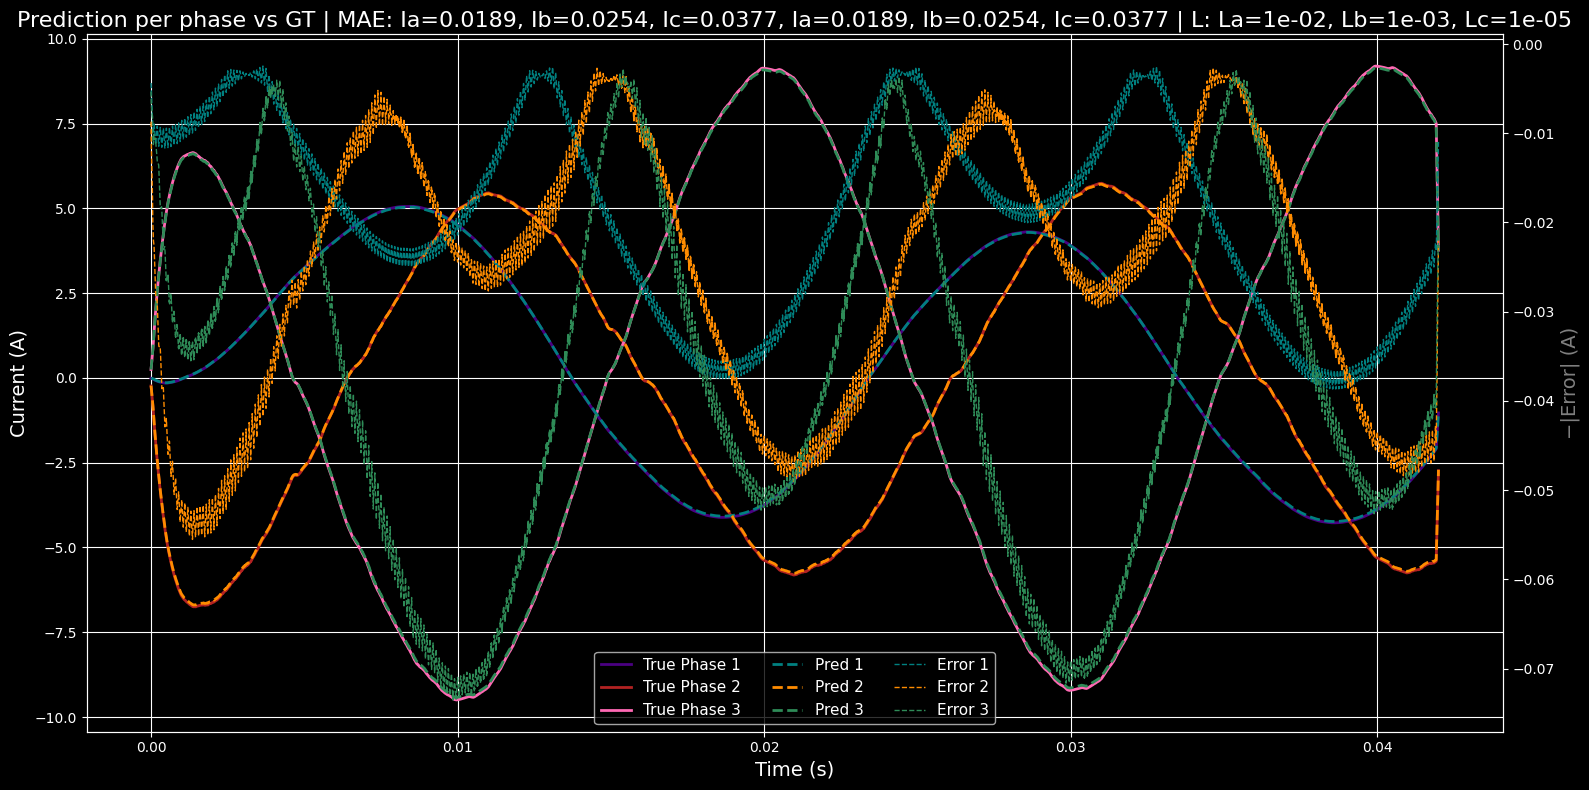

In [197]:
plot_prediction_vs_truth_1model_multi_phase(
    csv_path='new_3_ph_igbt_leg_La=1e-2_Lb=1e-3_Lc=1e-5_time_step_5e-7.csv',
    model=FeedforwardNet(hidden_layers=7, neurons_per_layer=64),
    name="1ph_inv_model_h7w64.pth",
    scaler_X=dataset.scaler_X,
    scaler_y=dataset.scaler_y,
    hidden_layers=7,
    neurons_per_layer=64,
    start_time=0.0,
    end_time=0.042,
    smooth=True,
    window_size=300,
    phases_to_display=[0, 1, 2],
    save_path="presentation_plot_highdpi_La=1e-2_Lb=1e-3_Lc=1e-5.png"
)


In [199]:
import numpy as np
from sklearn.metrics import mean_absolute_error

def recursive_rolling_mean(arr, window=250, threshold=1e-9, max_iters=1000):
    """
    Rekurzivno primenjuje rolling mean dok MAE između dva uzastopna
    smirena rezultata ne padne ispod zadatog praga.
    """
    prev = arr.copy()
    for i in range(max_iters):
        smoothed = np.convolve(prev, np.ones(window)/window, mode='same')
        mae = mean_absolute_error(prev, smoothed)
        if mae < threshold:
            print(f"✅ Stopped at iteration {i+1} (MAE={mae:.6f})")
            return smoothed
        prev = smoothed
    print(f"⚠️ Max iterations reached ({max_iters}), final MAE={mae:.6f}")
    return smoothed


In [200]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
import re

def rolling_mean(arr, window=200):
    return np.convolve(arr, np.ones(window) / window, mode='same')

def plot_prediction_vs_truth_1model_multi_phase_recursive(
    csv_path,
    model,
    name,
    scaler_X,
    scaler_y,
    hidden_layers,
    neurons_per_layer,
    start_time,
    end_time,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    phases_to_display=[0, 1, 2],
    smooth=True,
    window_size=200,
    save_path="prediction_vs_truth_highres.png"
):
    model.load_state_dict(torch.load(name, map_location=device))
    model.to(device)
    model.eval()

    match_all = re.findall(r"L([abc])=([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)", csv_path)
    L_values = {key: float(val) for key, val in match_all}
    L_text = ", ".join([f"L{key}={L_values.get(key, 'NA'):.0e}" for key in ['a', 'b', 'c']])


    df = pd.read_csv(csv_path)

    inputs_per_phase = {
        0: df[['Ia', 'topA', 'botA', 'time_step', "La_value"]].values.astype(np.float32),
        1: df[['Ib', 'topB', 'botB', 'time_step', "Lb_value"]].values.astype(np.float32),
        2: df[['Ic', 'topC', 'botC', 'time_step', "Lc_value"]].values.astype(np.float32),
    }

    targets = df[['Ia_next_value', 'Ib_next_value', 'Ic_next_value']].values.astype(np.float32)
    next_time = df["time"].values + df["time_step"].values

    preds = []
    for i in phases_to_display:
        X = inputs_per_phase[i]
        X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
        with torch.no_grad():
            y_pred = model(X_tensor).cpu().numpy()
        preds.append(y_pred)

    y_pred_all = np.concatenate(preds, axis=1)
    y_true_all = targets

    mask = (next_time >= start_time) & (next_time <= end_time)
    plt.style.use("dark_background")
    fig, ax1 = plt.subplots(figsize=(16, 8))
    phase_colors = ["teal", "darkorange", "seagreen"]
    truth_colors = ["indigo", "firebrick", "hotpink"]

    mae_texts = []
    for idx, phase in enumerate(phases_to_display):
        true_vals = y_true_all[mask, phase]
        pred_vals = y_pred_all[mask, idx]
        mae = mean_absolute_error(true_vals, pred_vals)
        mae_texts.append(f"I{chr(97 + phase)}={mae:.4f}")

        ax1.plot(next_time[mask], true_vals, color=truth_colors[phase], alpha = 0.3, linewidth=2.7)

    for idx, phase in enumerate(phases_to_display):
        true_vals = y_true_all[mask, phase]
        pred_vals = y_pred_all[mask, idx]
        mae = mean_absolute_error(true_vals, pred_vals)
        mae_texts.append(f"I{chr(97 + phase)}={mae:.4f}")

        ax1.plot(next_time[mask], pred_vals, color=phase_colors[phase], alpha = 0.3, linestyle='--')
        
    for idx, phase in enumerate(phases_to_display):
        true_vals = y_true_all[mask, phase]
        pred_vals = y_pred_all[mask, idx]
        mae = mean_absolute_error(true_vals, pred_vals)
        mae_texts.append(f"I{chr(97 + phase)}={mae:.4f}")

        if smooth:
            true_vals = recursive_rolling_mean(true_vals, window=window_size)
            pred_vals = recursive_rolling_mean(pred_vals, window=window_size)

        ax1.plot(next_time[mask], true_vals, color="maroon", alpha=1, linewidth=0.7, label=f"True Phase {i+1}")

    for idx, phase in enumerate(phases_to_display):
        true_vals = y_true_all[mask, phase]
        pred_vals = y_pred_all[mask, idx]
        mae = mean_absolute_error(true_vals, pred_vals)
        mae_texts.append(f"I{chr(97 + phase)}={mae:.4f}")

        if smooth:
            true_vals = recursive_rolling_mean(true_vals, window=window_size)
            pred_vals = recursive_rolling_mean(pred_vals, window=window_size)

        ax1.plot(next_time[mask], pred_vals, color=phase_colors[phase], linestyle='--', linewidth=2, label=f"Pred {phase + 1}")


    ax1.set_xlabel("Time (s)", fontsize=14)
    ax1.set_ylabel("Current (A)", fontsize=14)
    ax1.grid(True)

    ax2 = ax1.twinx()
    for idx, phase in enumerate(phases_to_display):
        err = -np.abs(y_true_all[mask, phase] - y_pred_all[mask, idx])
        if smooth:
            err = recursive_rolling_mean(err, window=window_size)
        ax2.plot(next_time[mask], err, color=phase_colors[phase], linestyle="--", linewidth=1, alpha=1, label=f"Error {phase + 1}")

    ax2.set_ylabel("−|Error| (A)", color='gray', fontsize=14)

    title = f"Prediction per phase vs GT | \n MAE: {', '.join(mae_texts)} | L: {L_text}"
    plt.title(title, fontsize=16)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower center", ncol=3, fontsize=11)
    plt.style.use("dark_background")

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"✅ Saved high-res figure to: {save_path}")
    plt.show()


⚠️ Max iterations reached (1000), final MAE=0.000267
⚠️ Max iterations reached (1000), final MAE=0.000265
⚠️ Max iterations reached (1000), final MAE=0.000317
⚠️ Max iterations reached (1000), final MAE=0.000315
⚠️ Max iterations reached (1000), final MAE=0.000549
⚠️ Max iterations reached (1000), final MAE=0.000545
⚠️ Max iterations reached (1000), final MAE=0.000267
⚠️ Max iterations reached (1000), final MAE=0.000265
⚠️ Max iterations reached (1000), final MAE=0.000317
⚠️ Max iterations reached (1000), final MAE=0.000315
⚠️ Max iterations reached (1000), final MAE=0.000549
⚠️ Max iterations reached (1000), final MAE=0.000545
⚠️ Max iterations reached (1000), final MAE=0.000001
⚠️ Max iterations reached (1000), final MAE=0.000002
⚠️ Max iterations reached (1000), final MAE=0.000004
✅ Saved high-res figure to: presentation_plot_highdpi_recursive_smooth_Lb=1e-3_Lc=1e-5_time_step_5e-7.png


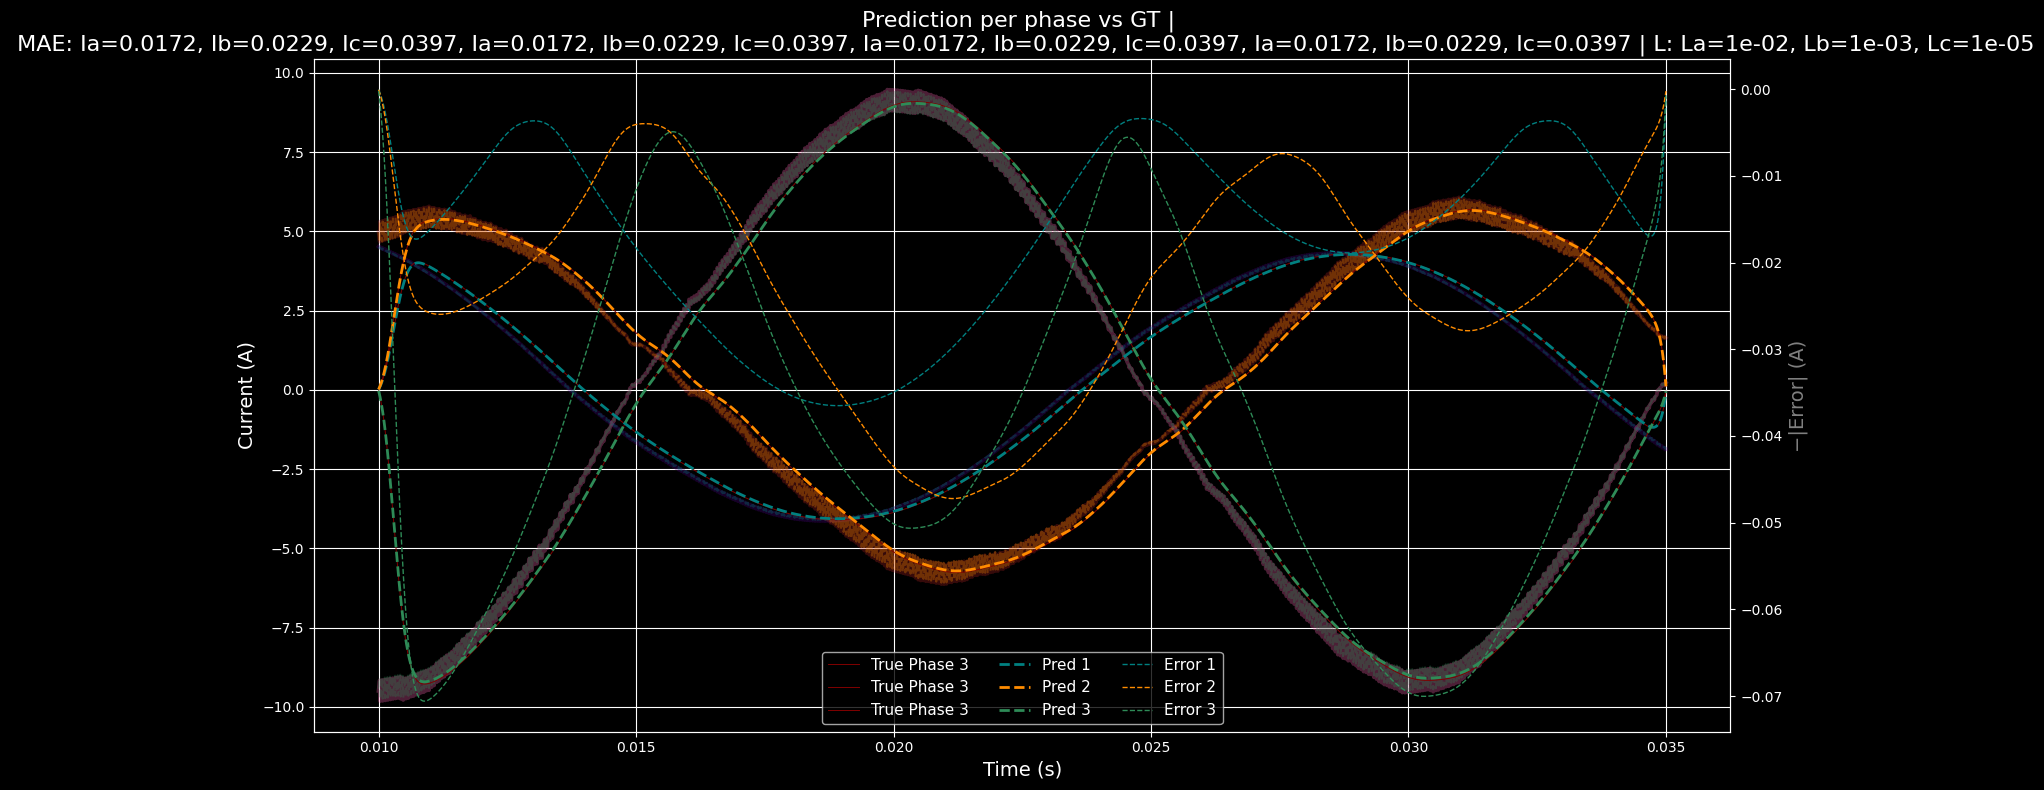

In [203]:
plot_prediction_vs_truth_1model_multi_phase_recursive(
    csv_path='new_3_ph_igbt_leg_La=1e-2_Lb=1e-3_Lc=1e-5_time_step_5e-7.csv',
    model=FeedforwardNet(hidden_layers=7, neurons_per_layer=64),
    name="1ph_inv_model_h7w64.pth",
    scaler_X=dataset.scaler_X,
    scaler_y=dataset.scaler_y,
    hidden_layers=7,
    neurons_per_layer=64,
    start_time=0.01,
    end_time=0.035,
    smooth=True,
    window_size=50,
    phases_to_display=[0, 1, 2],
    save_path="presentation_plot_highdpi_recursive_smooth_Lb=1e-3_Lc=1e-5_time_step_5e-7.png"
)

⚠️ Max iterations reached (1000), final MAE=0.000075
⚠️ Max iterations reached (1000), final MAE=0.000075
⚠️ Max iterations reached (1000), final MAE=0.000420
⚠️ Max iterations reached (1000), final MAE=0.000417
⚠️ Max iterations reached (1000), final MAE=0.000354
⚠️ Max iterations reached (1000), final MAE=0.000352
⚠️ Max iterations reached (1000), final MAE=0.000075
⚠️ Max iterations reached (1000), final MAE=0.000075
⚠️ Max iterations reached (1000), final MAE=0.000420
⚠️ Max iterations reached (1000), final MAE=0.000417
⚠️ Max iterations reached (1000), final MAE=0.000354
⚠️ Max iterations reached (1000), final MAE=0.000352
⚠️ Max iterations reached (1000), final MAE=0.000001
⚠️ Max iterations reached (1000), final MAE=0.000003
⚠️ Max iterations reached (1000), final MAE=0.000002
✅ Saved high-res figure to: presentation_plot_highdpi_recursive_max_smooth_La=5e-4_Lb=3e-2_Lc=4e-6.png


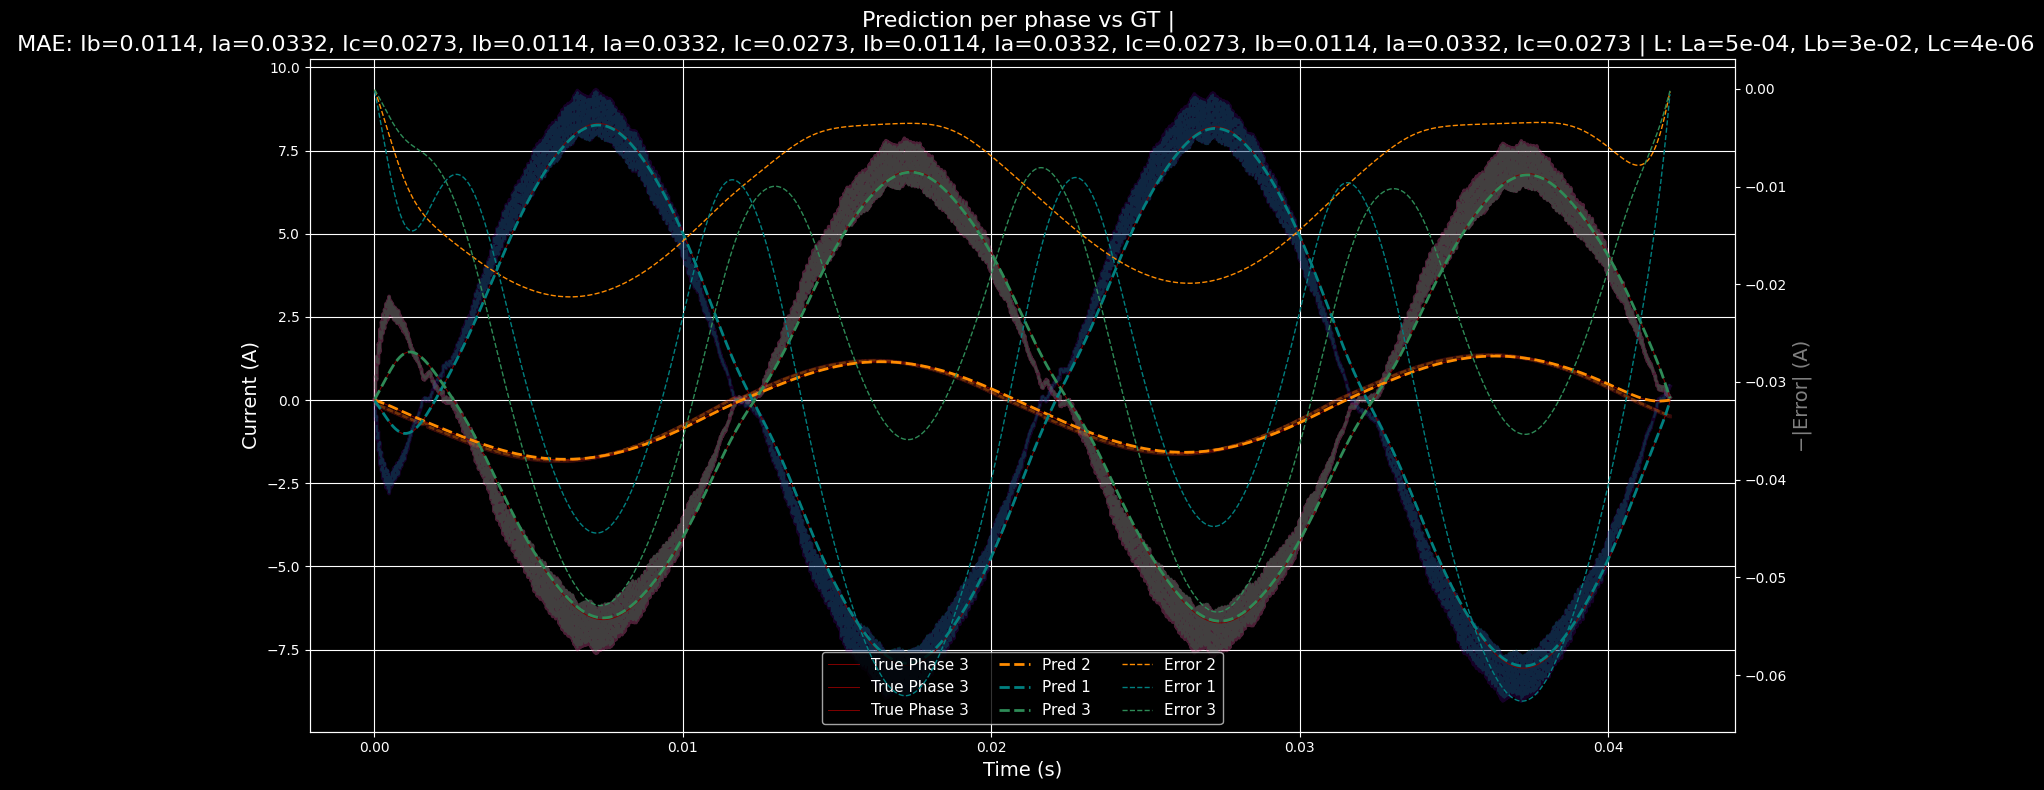

In [205]:
plot_prediction_vs_truth_1model_multi_phase_recursive(
    csv_path='new_3_ph_igbt_leg_La=5e-4_Lb=3e-2_Lc=4e-6_time_step_5e-7.csv',
    model=FeedforwardNet(hidden_layers=7, neurons_per_layer=64),
    name="1ph_inv_model_h7w64.pth",
    scaler_X=dataset.scaler_X,
    scaler_y=dataset.scaler_y,
    hidden_layers=7,
    neurons_per_layer=64,
    start_time=0.0,
    end_time=0.042,
    smooth=True,
    window_size=150,
    phases_to_display=[1, 0, 2],
    save_path="presentation_plot_highdpi_recursive_max_smooth_La=5e-4_Lb=3e-2_Lc=4e-6.png"
)